In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.backends.cudnn as cudnn
import torchvision
import torchvision.transforms as transforms
import os
import argparse
from pathlib import Path
import re
import random
import math
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from pathlib import Path
import re, random, math, os
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve
from sklearn.model_selection import StratifiedKFold, train_test_split

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
save_dir  = "/content/drive/MyDrive/CD/2Bio_SHAP_node6/"
K_FOLDS          = 7
BATCH_SIZE =3

TRAIN_ADD_GAUSS_NOISE = True
TRAIN_NOISE_FRAC      = 0.0   # set >0 to actually add noise
TRAIN_NOISE_PROB      = 1.0
EPS_STD               = 1e-8

### Reading the BF data

In [ ]:
bf_path = '/content/drive/MyDrive/ALL_CLEAN_DEIDEN_NAME AND ECMO DATA(Sheet1) (1) (version 2).csv'
cols = ['ID','age_days', 'Diagnosis', 'sex (1:M, 2:F)']
df = pd.read_csv(bf_path, usecols=cols)

s = pd.to_numeric(df['age_days'], errors='coerce')
df['age_days'] = pd.cut(s, [0,10,100,1000,np.inf], labels=[0,1,2,3],
                        include_lowest=True).astype('Int64')
for col in ['age_days']:
    s = pd.to_numeric(df[col], errors='coerce')
    mx = s.max(skipna=True)
    if pd.notna(mx) and mx != 0:
        df[col] = s / (mx*2)
    else:
        df[col] = s

diag_clean = (
    df['Diagnosis']
      .astype('string')
      .str.strip()
      .str.replace(r'\s+', ' ', regex=True)
      .fillna('Unknown')
)

codes, uniques = pd.factorize(diag_clean, sort=True)
df['Diagnosis'] = codes.astype('int64')
diagnosis_mapping = {cat: int(i) for i, cat in enumerate(uniques)}

In [ ]:
df.head()

,ID,"sex (1:M, 2:F)",age_days,Diagnosis
0,1,1,0.333333,0
1,2,1,0.333333,0
2,3,2,0.5,3
3,4,1,0.0,2
4,5,2,0.0,2


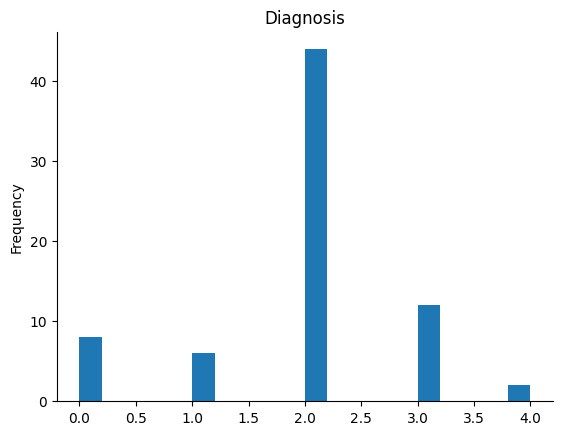

In [ ]:
from matplotlib import pyplot as plt
df['Diagnosis'].plot(kind='hist', bins=20, title='Diagnosis')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
from pathlib import Path
import re, random, math, os
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve
from sklearn.model_selection import StratifiedKFold, train_test_split

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# =========================
# Config
# =========================
SPLIT_DIR =  r"/content/drive/MyDrive/CD/patient_data_clean_nozero_181920212223_1800_v3"
POS_PATIENTS = {1, 2, 16, 19, 21, 22, 25, 37, 39, 43, 44, 47, 50, 56, 58, 62, 65, 66, 73, 78}

BATCH_SIZE       = 3
EPOCHS           = 100
LR               = 1e-4
SEED             = 1
K_FOLDS          = 7

# (kept for reference; not used to fix height)
TARGET_H = 400

# =========================
# Noise config (train-time augmentation only, EEG input only)
# =========================
TRAIN_ADD_GAUSS_NOISE = True
TRAIN_NOISE_FRAC      = 0.0   # set >0 to actually add noise
TRAIN_NOISE_PROB      = 1.0
EPS_STD               = 1e-8

# Ensure base save dir exists
Path(save_dir).mkdir(parents=True, exist_ok=True)

# =========================
# Repro
# =========================
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
for g in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass

# =========================
# Helpers
# =========================
PATIENT_NUM_RX = re.compile(r'^ID(\d+)')  # e.g., "ID76-2_..." -> 76

def patient_num_from_path(pathlike):
    stem = Path(pathlike).stem
    m = PATIENT_NUM_RX.match(stem)
    return int(m.group(1)) if m else None

def label_for_id(pid: int) -> int:
    return 1 if pid in POS_PATIENTS else 0

def label_for_file(p: Path) -> int:
    pid = patient_num_from_path(p)
    return label_for_id(pid) if pid is not None else 0

# =========================
# Load your existing features DataFrame: must exist as `df`
# Columns: 'ID' + your feature columns (3 in your current setup)
# =========================
feats_df = df.copy()  # <-- expects `df` already in memory
if "ID" not in feats_df.columns:
    raise RuntimeError("Your features DataFrame must contain column 'ID'.")

FEAT_COLS = [c for c in feats_df.columns if c != "ID"]
FEAT_DIM = len(FEAT_COLS)
print("FEAT_DIM =", FEAT_DIM)

# Clean and index by ID; drop rows with missing any of the features
feats_df["ID"] = pd.to_numeric(feats_df["ID"], errors="coerce").astype("Int64")
feats_df = feats_df.dropna(subset=["ID"] + FEAT_COLS).copy()
feats_df["ID"] = feats_df["ID"].astype(int)
ID_TO_FEAT = {
    int(row["ID"]): row[FEAT_COLS].astype("float32").to_numpy()
    for _, row in feats_df.iterrows()
}

# =========================
# Enumerate EEG files and keep only IDs present in features
# =========================
split_dir = Path(SPLIT_DIR)
all_csvs = sorted(split_dir.glob("*.csv"))
if not all_csvs:
    raise FileNotFoundError(f"No CSV found in {SPLIT_DIR}")

id_to_files = {}
for f in all_csvs:
    pid = patient_num_from_path(f)
    if pid is None:
        continue
    if pid in ID_TO_FEAT:  # keep only IDs with features
        id_to_files.setdefault(pid, []).append(f)

valid_ids = sorted(id_to_files.keys())
if not valid_ids:
    raise RuntimeError("No overlapping patient IDs between files and features table.")
y_ids = np.array([label_for_id(pid) for pid in valid_ids], dtype=int)
print("Total valid IDs:", len(valid_ids), "| Pos IDs:", y_ids.sum(), "| Neg IDs:", (1 - y_ids).sum())

# =========================
# Utilities for loading & shaping EEG (de-dup consecutive rows)
# =========================
def _drop_time_cols(df: pd.DataFrame) -> pd.DataFrame:
    time_like = [c for c in df.columns if isinstance(c, str) and c.strip().lower() == "time"]
    return df.drop(columns=time_like, errors="ignore")

def _to_numeric_df(df: pd.DataFrame) -> pd.DataFrame:
    df = _drop_time_cols(df)
    return df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

def _pad_crop_2d(x: np.ndarray, H: int, W: int) -> np.ndarray:
    h, w = x.shape
    if h < H:
        pad = np.zeros((H, w), dtype=x.dtype); pad[:h, :] = x; x = pad; h = H
    elif h > H:
        x = x[:H, :]; h = H
    if w < W:
        pad = np.zeros((h, W), dtype=x.dtype); pad[:, :w] = x; x = pad
    elif w > W:
        x = x[:, :W]
    return x

def _dedupe_consecutive_rows(mat: np.ndarray) -> np.ndarray:
    if mat.size == 0:
        return mat
    if mat.ndim == 1:
        mat = mat[:, None]
    if mat.shape[0] == 1:
        return mat
    diffs = np.any(mat[1:] != mat[:-1], axis=1)
    keep = np.concatenate(([True], diffs))
    return mat[keep]

def _infer_target_width(example_csv: Path) -> int:
    df0 = pd.read_csv(example_csv)
    df2 = _to_numeric_df(df0)
    return df2.shape[1]

# Width is fixed by columns in first valid sample
TARGET_W = _infer_target_width(id_to_files[valid_ids[0]][0])
print(f"TARGET_W={TARGET_W} (non-Time columns)")

# Height: max de-dup length across ALL eligible files (fixed for all folds)
def _dedup_len_from_csv(p: Path) -> int:
    dfx = pd.read_csv(p)
    mat = _to_numeric_df(dfx).to_numpy(dtype=np.float32)
    mat_d = _dedupe_consecutive_rows(mat)
    return int(mat_d.shape[0])

ALL_ELIGIBLE_FILES = [f for pid in valid_ids for f in id_to_files[pid]]
TARGET_H_DEDUP = max(_dedup_len_from_csv(f) for f in ALL_ELIGIBLE_FILES)
if TARGET_H_DEDUP <= 0:
    raise RuntimeError("After de-dup, zero-length found in data.")
print(f"Fixed input height after de-dup (all IDs): H={TARGET_H_DEDUP}")

def load_csv_as_image_dedup(csv_path: Path) -> np.ndarray:
    df0 = pd.read_csv(csv_path)
    df2 = _to_numeric_df(df0)
    mat = df2.to_numpy(dtype=np.float32)
    if mat.ndim != 2:
        mat = mat.reshape(mat.shape[0], -1) if mat.ndim > 2 else mat
    mat = _dedupe_consecutive_rows(mat)
    if mat.shape[0] == 0:
        mat = np.zeros((1, TARGET_W), dtype=np.float32)
    mat = _pad_crop_2d(mat, TARGET_H_DEDUP, TARGET_W)
    img = np.expand_dims(mat, axis=-1).astype(np.float32)  # (H, W, 1)
    if img.shape != (TARGET_H_DEDUP, TARGET_W, 1):
        raise ValueError(f"loader produced {img.shape}, expected {(TARGET_H_DEDUP, TARGET_W, 1)}")
    return img

CACHE_DEDUP = {}
def load_csv_as_image_cached(csv_path: Path) -> np.ndarray:
    key = str(csv_path)
    if key in CACHE_DEDUP:
        return CACHE_DEDUP[key]
    img = load_csv_as_image_dedup(csv_path)
    CACHE_DEDUP[key] = img
    return img


class ImageSequence(keras.utils.Sequence):
    def __init__(self, files, batch_size=BATCH_SIZE, shuffle=True,
                 add_noise=False, noise_frac=TRAIN_NOISE_FRAC, noise_prob=TRAIN_NOISE_PROB):
        super().__init__()
        self.files = list(files)
        self.batch_size = int(batch_size)
        self.shuffle = shuffle
        self.add_noise = add_noise
        self.noise_frac = float(noise_frac)
        self.noise_prob = float(noise_prob)
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.files) / self.batch_size)

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.files))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __getitem__(self, idx):
        idxs = self.indexes[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_files = [self.files[i] for i in idxs]
        B = len(batch_files)

        X_img = np.empty((B, TARGET_H_DEDUP, TARGET_W, 1), dtype=np.float32)
        X_tab = np.empty((B, FEAT_DIM), dtype=np.float32)
        y     = np.empty((B,), dtype=np.int32)

        for i, f in enumerate(batch_files):
            xi = load_csv_as_image_cached(f)
            if xi.ndim == 2:
                xi = xi[..., None]
            if xi.shape != (TARGET_H_DEDUP, TARGET_W, 1):
                raise ValueError(f"Sample shape {xi.shape} for {f}")
            X_img[i] = xi
            pid = patient_num_from_path(f)
            X_tab[i] = ID_TO_FEAT[pid]
            y[i] = label_for_file(f)

        # Gaussian noise on EEG only (train)
        if self.add_noise and self.noise_frac > 0.0 and self.noise_prob > 0.0:
            samp_std = X_img.reshape(B, -1).std(axis=1).astype(np.float32)
            samp_std = np.maximum(samp_std, EPS_STD).reshape(B, 1, 1, 1)
            noise = np.random.normal(0.0, 1.0, size=X_img.shape).astype(np.float32)
            noise *= (self.noise_frac * samp_std)
            if self.noise_prob < 1.0:
                mask = (np.random.rand(B, 1, 1, 1) < self.noise_prob).astype(np.float32)
                noise *= mask
            X_img = X_img + noise

        return {"eeg_input": X_img, "tab_input": X_tab}, y

FEAT_DIM = 3
Total valid IDs: 44 | Pos IDs: 14 | Neg IDs: 30
TARGET_W=6 (non-Time columns)
Fixed input height after de-dup (all IDs): H=360


### AUCROC

Fold 01 | TEST AUC = 0.7116 | n=275


Fold 02 | TEST AUC = 0.9250 | n=152
Fold 03 | TEST AUC = 0.7929 | n=191


Fold 04 | TEST AUC = 0.9724 | n=106


Fold 05 | TEST AUC = 0.9624 | n=105


Fold 06 | TEST AUC = 0.9853 | n=205


Fold 07 | TEST AUC = 1.0000 | n=186


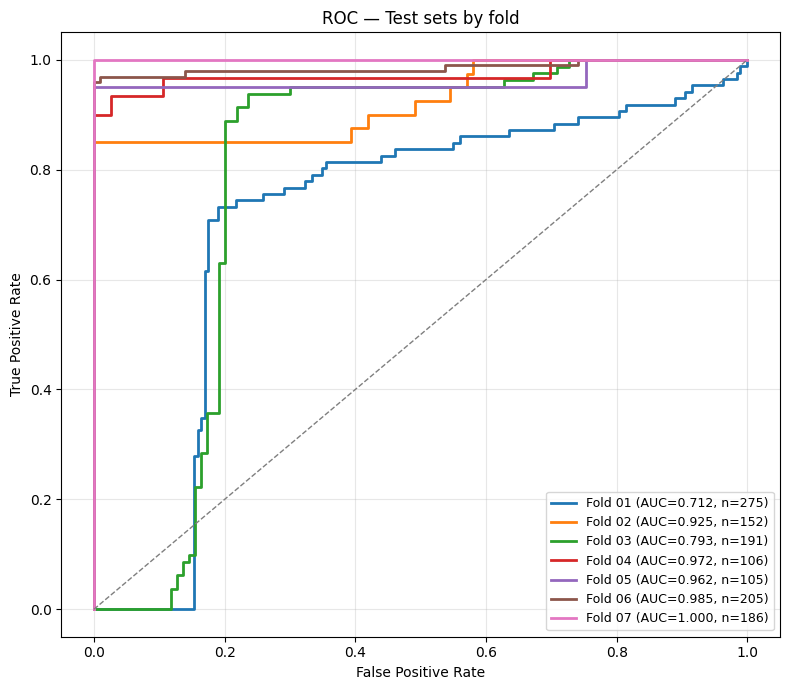

Saved combined ROC plot to: /content/drive/MyDrive/CD/2Bio_SHAP_node6/roc_curves_all_folds.png


In [ ]:
# === Load per-fold weights & test sets, plot ROC with AUC for each fold ===
# Assumes these are already defined from your training script:
#   save_dir, K_FOLDS, BATCH_SIZE, ImageSequence, label_for_file
#   (and all data-loading helpers/ID_TO_FEAT used by ImageSequence)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from tensorflow import keras

K_FOLDS          = 7
BATCH_SIZE =3

auc_rows = []
roc_data = []  # list of (fold_idx, fpr, tpr, auc, n)

for fold_idx in range(1, K_FOLDS + 1):
    fold_dir = Path(save_dir) / f"fold_{fold_idx:02d}"
    weights_file = fold_dir / f"best_fold_{fold_idx:02d}.h5"
    test_list = fold_dir / "test_files.txt"

    if not weights_file.exists() or not test_list.exists():
        print(f"(Fold {fold_idx:02d}) Missing weights or test_files.txt; skipping.")
        continue

    # Load test file paths
    test_files = [Path(line.strip()) for line in test_list.read_text().splitlines() if line.strip()]
    if len(test_files) == 0:
        print(f"(Fold {fold_idx:02d}) Empty test set; skipping.")
        continue

    # Eval generator (no shuffle, no noise)
    test_gen = ImageSequence(test_files, batch_size=BATCH_SIZE, shuffle=False, add_noise=False)

    # Load model and predict
    model = keras.models.load_model(str(weights_file))
    probs = model.predict(test_gen, verbose=0).ravel().astype(float)
    y_true = np.array([label_for_file(f) for f in test_gen.files], dtype=int)

    if len(np.unique(y_true)) < 2:
        print(f"(Fold {fold_idx:02d}) Only one class present; ROC/AUC undefined.")
        auc_rows.append({"fold": fold_idx, "n": len(y_true), "auc": np.nan})
        continue

    fpr, tpr, _ = roc_curve(y_true, probs)
    auc_val = roc_auc_score(y_true, probs)

    auc_rows.append({"fold": fold_idx, "n": len(y_true), "auc": float(auc_val)})
    roc_data.append((fold_idx, fpr, tpr, auc_val, len(y_true)))
    print(f"Fold {fold_idx:02d} | TEST AUC = {auc_val:.4f} | n={len(y_true)}")

# Save AUCs table
if auc_rows:
    auc_df = pd.DataFrame(auc_rows).sort_values("fold")
    #auc_df.to_csv(Path(save_dir) / "auc_by_fold.csv", index=False)

# Plot all ROC curves in one figure with AUC in legend
if roc_data:
    plt.figure(figsize=(8, 7))
    for fold_idx, fpr, tpr, auc_val, n in roc_data:
        plt.plot(fpr, tpr, linewidth=2, label=f"Fold {fold_idx:02d} (AUC={auc_val:.3f}, n={n})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC — Test sets by fold")
    plt.legend(loc="lower right", fontsize=9, frameon=True)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    out_png = Path(save_dir) / "roc_curves_all_folds.png"
    #plt.savefig(out_png, dpi=200)
    plt.show()
    print(f"Saved combined ROC plot to: {out_png}")
else:
    print("No ROC data plotted (no valid folds).")

In [ ]:
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
from tensorflow import keras  # only used if we need to recompute predictions

# Assumes these already exist from your training script:
# save_dir, K_FOLDS, BATCH_SIZE, ImageSequence, label_for_file, patient_num_from_path, label_for_id

SAVE_DIR = Path(save_dir)

# master dict: {fold_idx: {patient_id: mean_prob}}
fold_patient_scores = {}
# optional helpers if you want labels & counts too
fold_patient_labels = {}
fold_patient_counts = {}

for fold_idx in range(1, K_FOLDS + 1):
    fold_dir = SAVE_DIR / f"fold_{fold_idx:02d}"
    pred_csv = fold_dir / "test_predictions.csv"

    # --- get predictions at the CSV level (file-level probs) ---
    if pred_csv.exists():
        dfp = pd.read_csv(pred_csv)
        # expected columns: file, patient_id, y_true, prob1
        if "patient_id" not in dfp.columns:
            # derive patient_id from file path name if not saved
            dfp["patient_id"] = [patient_num_from_path(Path(p)) for p in dfp["file"]]
    else:
        # fall back to recompute from weights + file list
        weights_file = fold_dir / f"best_fold_{fold_idx:02d}.h5"
        test_list    = fold_dir / "test_files.txt"
        if not weights_file.exists() or not test_list.exists():
            print(f"(Fold {fold_idx:02d}) Missing predictions/weights/test list; skipping.")
            continue

        test_files = [Path(line.strip()) for line in test_list.read_text().splitlines() if line.strip()]
        if len(test_files) == 0:
            print(f"(Fold {fold_idx:02d}) Empty test set; skipping.")
            continue

        test_gen = ImageSequence(test_files, batch_size=BATCH_SIZE, shuffle=False, add_noise=False)
        model    = keras.models.load_model(str(weights_file))
        probs    = model.predict(test_gen, verbose=0).ravel().astype(float)
        y_true   = np.array([label_for_file(f) for f in test_gen.files], dtype=int)
        pids     = [patient_num_from_path(f) for f in test_gen.files]

        dfp = pd.DataFrame({
            "file": [str(f) for f in test_gen.files],
            "patient_id": pids,
            "y_true": y_true,
            "prob1": probs
        })
        # also save for traceability
        dfp.to_csv(pred_csv, index=False)

    # --- aggregate to patient-level means ---
    sums   = defaultdict(float)
    counts = defaultdict(int)
    labels = {}  # patient_id -> label (use first occurrence; should be consistent per patient)

    for _, row in dfp.iterrows():
        pid = int(row["patient_id"])
        pr  = float(row["prob1"])
        sums[pid]   += pr
        counts[pid] += 1
        if pid not in labels:
            # derive label either from the CSV if present or from your POS_PATIENTS mapping
            labels[pid] = int(row["y_true"]) if "y_true" in dfp.columns else int(label_for_id(pid))

    # build per-patient table for this fold
    patient_ids = sorted(sums.keys())
    mean_probs  = {pid: (sums[pid] / counts[pid]) for pid in patient_ids}

    fold_patient_scores[fold_idx] = mean_probs
    fold_patient_counts[fold_idx] = {pid: counts[pid] for pid in patient_ids}
    fold_patient_labels[fold_idx] = {pid: labels[pid] for pid in patient_ids}

    # save a tidy CSV for the fold
    out_df = pd.DataFrame({
        "patient_id": patient_ids,
        "n_files": [counts[pid] for pid in patient_ids],
        "mean_prob": [mean_probs[pid] for pid in patient_ids],
        "y_true": [labels[pid] for pid in patient_ids],
    }).sort_values(["y_true", "mean_prob", "patient_id"], ascending=[False, False, True])
    out_df.to_csv(fold_dir / "patient_mean_scores.csv", index=False)

    print(f"(Fold {fold_idx:02d}) saved patient_mean_scores.csv with {len(patient_ids)} patients.")

# Optional: save all-fold dictionaries to disk for later reuse
# (JSON is human-readable; note keys become strings)
import json
(SAVE_DIR / "per_patient").mkdir(exist_ok=True)
with open(SAVE_DIR / "per_patient" / "fold_patient_scores.json", "w") as f:
    json.dump(fold_patient_scores, f, indent=2)
with open(SAVE_DIR / "per_patient" / "fold_patient_counts.json", "w") as f:
    json.dump(fold_patient_counts, f, indent=2)
with open(SAVE_DIR / "per_patient" / "fold_patient_labels.json", "w") as f:
    json.dump(fold_patient_labels, f, indent=2)

print("Done. Dictionaries available as fold_patient_scores / _counts / _labels.")


(Fold 01) saved patient_mean_scores.csv with 7 patients.
(Fold 02) saved patient_mean_scores.csv with 7 patients.
(Fold 03) saved patient_mean_scores.csv with 6 patients.
(Fold 04) saved patient_mean_scores.csv with 6 patients.
(Fold 05) saved patient_mean_scores.csv with 6 patients.
(Fold 06) saved patient_mean_scores.csv with 6 patients.
(Fold 07) saved patient_mean_scores.csv with 6 patients.
Done. Dictionaries available as fold_patient_scores / _counts / _labels.


In [ ]:
from pathlib import Path
import pandas as pd

def _print_df(df, title):
    print(f"\n=== {title} ===")
    with pd.option_context('display.max_rows', None,
                           'display.float_format', '{:.4f}'.format):
        print(df.to_string(index=False))

BASE = Path(save_dir)

for fold_idx in range(1, K_FOLDS + 1):
    title = f"Fold {fold_idx:02d} — per-patient mean scores (TEST)"
    try:
        # If dictionaries are already in memory:
        mp = fold_patient_scores[fold_idx]
        cnt = fold_patient_counts[fold_idx]
        lab = fold_patient_labels[fold_idx]
        df = pd.DataFrame({
            "patient_id": list(mp.keys()),
            "n_files":    [cnt[pid] for pid in mp],
            "mean_prob":  [mp[pid]  for pid in mp],
            "y_true":     [lab[pid] for pid in mp],
        })
    except Exception:
        # Fallback: load the CSV saved earlier
        csv_path = BASE / f"fold_{fold_idx:02d}" / "patient_mean_scores.csv"
        if not csv_path.exists():
            print(f"(Fold {fold_idx:02d}) No data found.")
            continue
        df = pd.read_csv(csv_path)

    # Order: positives first, then by higher mean_prob
    df = df.sort_values(["y_true", "mean_prob", "patient_id"],
                        ascending=[False, False, True]).reset_index(drop=True)
    _print_df(df, title)



=== Fold 01 — per-patient mean scores (TEST) ===
 patient_id  n_files  mean_prob  y_true
         43       81     0.1388       1
         47        5     0.0153       1
          6      120     0.1476       0
         20       14     0.0628       0
         49       38     0.0376       0
          8       16     0.0250       0
         36        1     0.0246       0

=== Fold 02 — per-patient mean scores (TEST) ===
 patient_id  n_files  mean_prob  y_true
          1       34     0.8512       1
         22        6     0.2717       1
         45       17     0.3745       0
         64        7     0.3349       0
          5       37     0.2746       0
         28       23     0.2572       0
         26       28     0.1292       0

=== Fold 03 — per-patient mean scores (TEST) ===
 patient_id  n_files  mean_prob  y_true
         78       77     0.1359       1
         37        4     0.0001       1
         54        1     0.1047       0
         34       40     0.0800       0
         5

### SHAP importance - need to rewrite!

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


<Figure size 800x600 with 0 Axes>

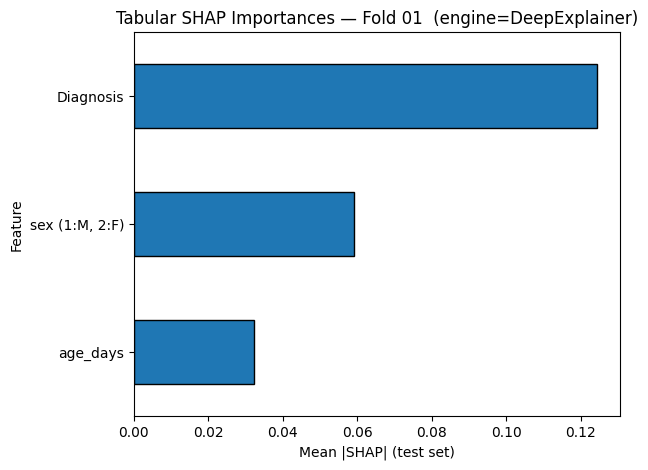

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


<Figure size 800x600 with 0 Axes>

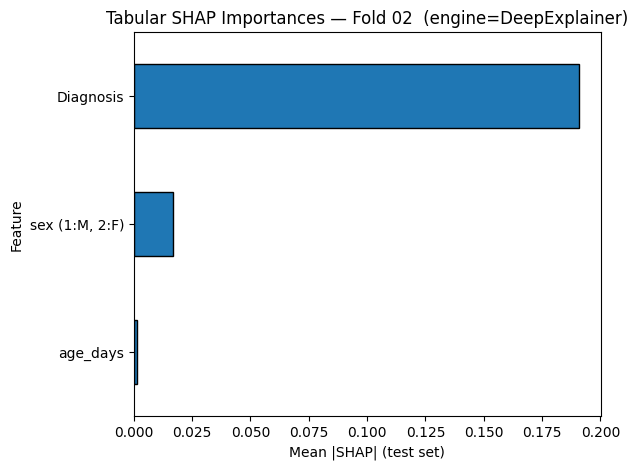

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


<Figure size 800x600 with 0 Axes>

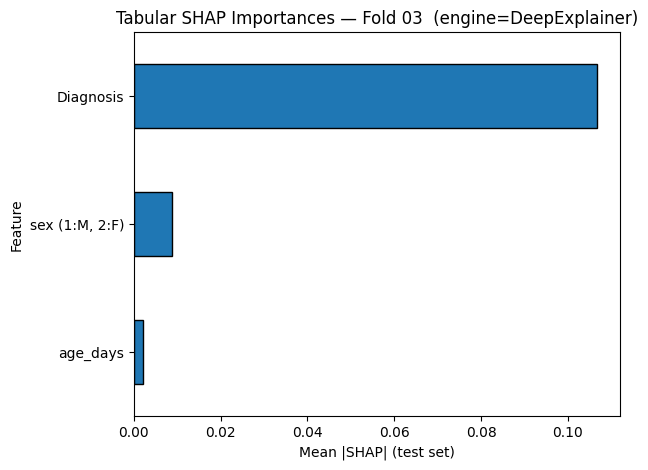

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


<Figure size 800x600 with 0 Axes>

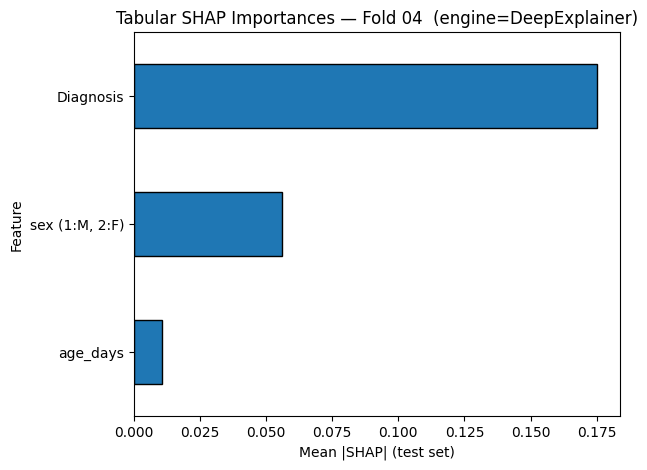

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


<Figure size 800x600 with 0 Axes>

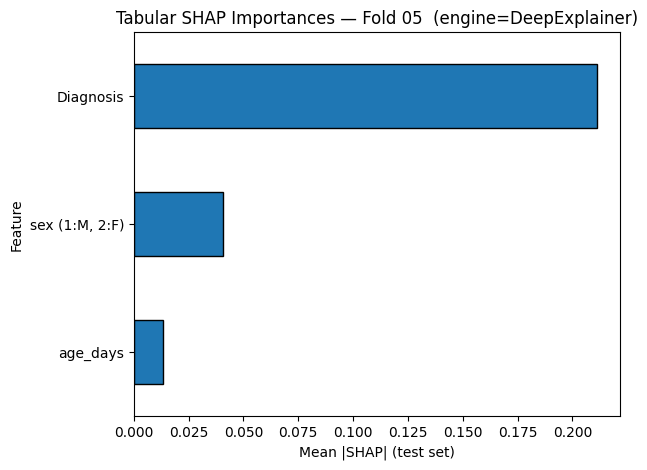

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


<Figure size 800x600 with 0 Axes>

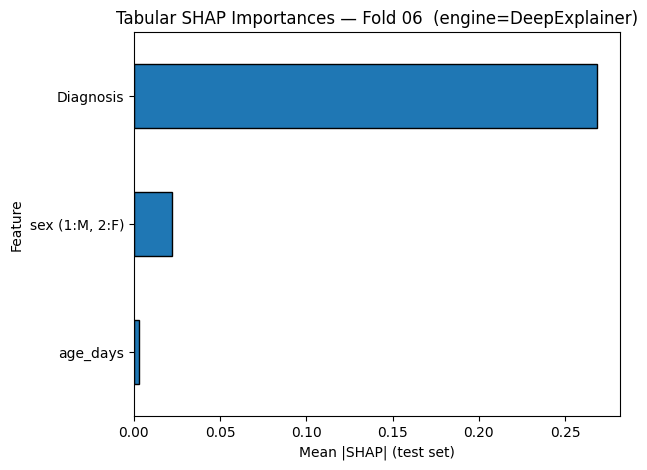

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


<Figure size 800x600 with 0 Axes>

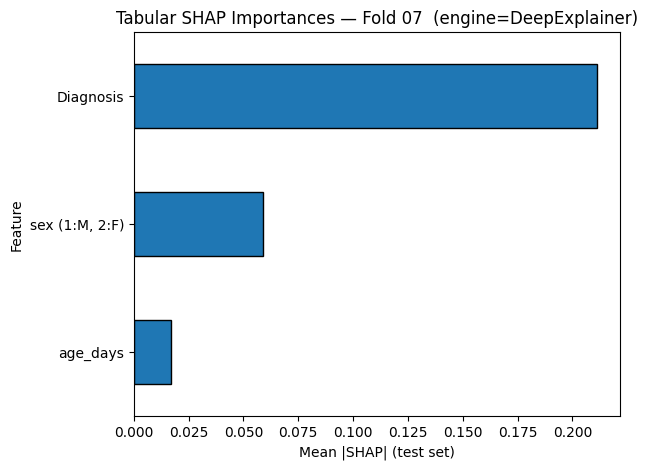


=== Tabular SHAP mean(|value|) by feature and fold ===
                 fold_01   fold_02   fold_03   fold_04   fold_05   fold_06   fold_07  mean_over_folds
Diagnosis       0.124328  0.190679  0.106676  0.175037  0.211145  0.268430  0.211180         0.183925
sex (1:M, 2:F)  0.059038  0.016668  0.008861  0.056020  0.040867  0.022032  0.058910         0.037485
age_days        0.032311  0.001342  0.002056  0.010823  0.013131  0.003172  0.017131         0.011424


In [ ]:
# === SHAP feature importances (tabular features) per fold on each fold's TEST set ===
# Assumes these are already defined in your session:
#   save_dir, K_FOLDS, BATCH_SIZE
#   FEAT_COLS, FEAT_DIM, TARGET_H_DEDUP, TARGET_W
#   ID_TO_FEAT, load_csv_as_image_cached, patient_num_from_path, label_for_file
# And for each fold directory:
#   .../fold_XX/best_fold_XX.h5
#   .../fold_XX/train_files.txt, .../fold_XX/test_files.txt, (optional) .../fold_XX/val_files.txt
#
# This script:
#   • Computes SHAP values for the *tabular* input on each fold’s TEST set
#   • Plots a bar chart of mean |SHAP| per feature for each fold (NO saving of plots)
#   • Collects per-fold importances into `fold_importances` (a list of Series)
#   • Prints a cross-fold table `imp_table` (features x folds) and a mean-over-folds row

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras

# Ensure SHAP is available
try:
    import shap
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap

# -------- tweakables --------
BACKGROUND_N = 32     # number of background samples (from train+val) to fit explainer
SHAP_BATCH   = 16     # SHAP computation batch size
TOP_K        = 20     # max features to display in each bar plot
# ---------------------------

rng = np.random.default_rng(1)
save_dir_path = Path(save_dir)

def _build_arrays(file_list):
    """Construct (X_img, X_tab, y) arrays for a list of CSV Paths."""
    n = len(file_list)
    X_img = np.empty((n, TARGET_H_DEDUP, TARGET_W, 1), dtype=np.float32)
    X_tab = np.empty((n, FEAT_DIM), dtype=np.float32)
    y     = np.empty((n,), dtype=np.int32)
    for i, f in enumerate(file_list):
        xi = load_csv_as_image_cached(f)
        if xi.ndim == 2:
            xi = xi[..., None]
        if xi.shape != (TARGET_H_DEDUP, TARGET_W, 1):
            raise ValueError(f"Bad EEG shape {xi.shape} for {f}")
        X_img[i] = xi
        pid = patient_num_from_path(f)
        X_tab[i] = ID_TO_FEAT[pid]
        y[i] = label_for_file(f)
    return X_img, X_tab, y

def _get_bg_files(train_files, val_files, k=BACKGROUND_N):
    """Pick up to k files from train+val as SHAP background."""
    pool = list(train_files) + list(val_files)
    if len(pool) == 0:
        pool = list(train_files)
    if len(pool) == 0:
        raise RuntimeError("No background data: train+val empty for this fold.")
    k = min(k, len(pool))
    idx = rng.choice(len(pool), size=k, replace=False)
    return [pool[i] for i in idx]

def _extract_tab_shap_2d(shap_vals, feat_dim_expected=None):
    """
    Return a (N, D) numpy array of SHAP values for the *tabular* input (2nd model input).
    Handles nesting and odd shapes like (1, N, D), (C, N, D), or (N, D, 1).
    """
    sv = shap_vals
    # Unwrap one level if SHAP returns [[sv_img, sv_tab]]
    if isinstance(sv, list) and len(sv) > 0 and isinstance(sv[0], list):
        sv = sv[0]

    # Tabular component is index 1 (since inputs=[eeg_input, tab_input])
    sv_tab = np.asarray(sv[1])

    # Normalize to (N, D)
    if sv_tab.ndim == 3:
        if sv_tab.shape[0] == 1:         # (1, N, D)
            sv_tab = sv_tab[0]
        elif sv_tab.shape[-1] == 1:      # (N, D, 1)
            sv_tab = sv_tab[..., 0]
        else:                            # (C, N, D) -> average across outputs/classes
            sv_tab = sv_tab.mean(axis=0)
    elif sv_tab.ndim == 1:
        sv_tab = sv_tab.reshape(1, -1)   # (D,) -> (1, D)

    # If axes swapped (D, N), transpose
    if sv_tab.ndim == 2 and feat_dim_expected is not None and sv_tab.shape[0] == feat_dim_expected and sv_tab.shape[1] != feat_dim_expected:
        sv_tab = sv_tab.T

    if sv_tab.ndim != 2:
        raise ValueError(f"Unexpected SHAP shape for tabular input: {sv_tab.shape}")

    if (feat_dim_expected is not None) and (sv_tab.shape[1] != feat_dim_expected):
        raise ValueError(f"SHAP D={sv_tab.shape[1]} != FEAT_DIM={feat_dim_expected}")

    return sv_tab

def _compute_tab_shap_in_batches(explainer, X_img, X_tab, batch=SHAP_BATCH):
    """Compute SHAP for the tabular input over (X_img, X_tab) in batches; returns (N, D)."""
    parts = []
    for i in range(0, X_tab.shape[0], batch):
        x_img_b = X_img[i:i+batch]
        x_tab_b = X_tab[i:i+batch]
        sv = explainer.shap_values([x_img_b, x_tab_b], check_additivity=False)
        shap_tab_b = _extract_tab_shap_2d(sv, feat_dim_expected=len(FEAT_COLS))
        parts.append(shap_tab_b)
    return np.concatenate(parts, axis=0)

# ---- Collect per-fold importances here ----
fold_importances = []  # list[pd.Series], index=FEAT_COLS, name=f"fold_XX"

for fold_idx in range(1, K_FOLDS + 1):
    fold_dir    = save_dir_path / f"fold_{fold_idx:02d}"
    weights_fp  = fold_dir / f"best_fold_{fold_idx:02d}.h5"
    test_list   = fold_dir / "test_files.txt"
    train_list  = fold_dir / "train_files.txt"
    val_list    = fold_dir / "val_files.txt"

    if not weights_fp.exists() or not test_list.exists() or not train_list.exists():
        print(f"(Fold {fold_idx:02d}) Missing weights/test/train lists; skipping SHAP.")
        continue

    # Load file lists
    test_files  = [Path(x) for x in test_list.read_text().splitlines()  if x.strip()]
    train_files = [Path(x) for x in train_list.read_text().splitlines() if x.strip()]
    val_files   = [Path(x) for x in (val_list.read_text().splitlines() if val_list.exists() else []) if x.strip()]

    if len(test_files) == 0:
        print(f"(Fold {fold_idx:02d}) Empty test set; skipping SHAP.")
        continue

    # Build arrays
    X_img_test, X_tab_test, y_true = _build_arrays(test_files)
    bg_files = _get_bg_files(train_files, val_files, k=BACKGROUND_N)
    X_img_bg, X_tab_bg, _ = _build_arrays(bg_files)

    # Load model
    model = keras.models.load_model(str(weights_fp))

    # Explainer: Deep -> Gradient -> generic
    try:
        explainer = shap.DeepExplainer(model, [X_img_bg, X_tab_bg])
        _ = explainer.shap_values([X_img_test[:1], X_tab_test[:1]], check_additivity=False)
        engine = "DeepExplainer"
    except Exception as e:
        print(f"(Fold {fold_idx:02d}) DeepExplainer failed ({e}); trying GradientExplainer.")
        try:
            explainer = shap.GradientExplainer(model, data=[X_img_bg, X_tab_bg])
            _ = explainer.shap_values([X_img_test[:1], X_tab_test[:1]], check_additivity=False)
            engine = "GradientExplainer"
        except Exception as e2:
            print(f"(Fold {fold_idx:02d}) GradientExplainer failed ({e2}); trying generic Explainer.")
            try:
                explainer = shap.Explainer(model, masker=[X_img_bg, X_tab_bg])
                _ = explainer([X_img_test[:1], X_tab_test[:1]])
                engine = "Explainer"
            except Exception as e3:
                print(f"(Fold {fold_idx:02d}) All SHAP explainers failed ({e3}); skipping.")
                continue

    # Compute SHAP for tabular on TEST -> (N, D)
    if engine == "Explainer":
        exp = explainer([X_img_test, X_tab_test])
        shap_tab = _extract_tab_shap_2d([exp.values[0], exp.values[1]], feat_dim_expected=len(FEAT_COLS))
    else:
        shap_tab = _compute_tab_shap_in_batches(explainer, X_img_test, X_tab_test, batch=SHAP_BATCH)

    # Mean |SHAP| per feature -> 1-D
    mean_abs = np.mean(np.abs(shap_tab), axis=0).ravel()
    imp_df = (
        pd.DataFrame({"feature": FEAT_COLS, "mean_abs_shap": mean_abs})
          .sort_values("mean_abs_shap", ascending=False)
    )

    # --- collect for later ---
    fold_importances.append(pd.Series(mean_abs, index=FEAT_COLS, name=f"fold_{fold_idx:02d}"))

    # --- plot (DO NOT SAVE) ---
    top_k = min(TOP_K, len(FEAT_COLS))
    plt.figure(figsize=(8, 6))
    imp_df.head(top_k)[::-1].plot(
        kind="barh", x="feature", y="mean_abs_shap",
        legend=False, edgecolor="black"
    )
    plt.xlabel("Mean |SHAP| (test set)")
    plt.ylabel("Feature")
    plt.title(f"Tabular SHAP Importances — Fold {fold_idx:02d}  (engine={engine})")
    plt.tight_layout()
    plt.show()

# ---- Cross-fold summary in-memory (no file saving) ----
if fold_importances:
    imp_table = pd.concat(fold_importances, axis=1)           # rows=features, cols=fold_XX
    imp_table["mean_over_folds"] = imp_table.mean(axis=1)
    print("\n=== Tabular SHAP mean(|value|) by feature and fold ===")
    print(imp_table.sort_values("mean_over_folds", ascending=False).to_string())
else:
    print("\nNo SHAP importances computed (no valid folds).")


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(



=== Four tabular features — mean(|SHAP|) on TEST by fold ===
                fold_01  fold_02  fold_03  fold_04  fold_05  fold_06  fold_07  mean_over_folds
Diagnosis      0.162131 0.191022 0.157813 0.189009 0.303152 0.243300 0.275235         0.217380
sex (1:M, 2:F) 0.052721 0.020358 0.016342 0.062981 0.072805 0.018986 0.032845         0.039577
age_days       0.022613 0.001246 0.003663 0.013650 0.009193 0.005316 0.014795         0.010068


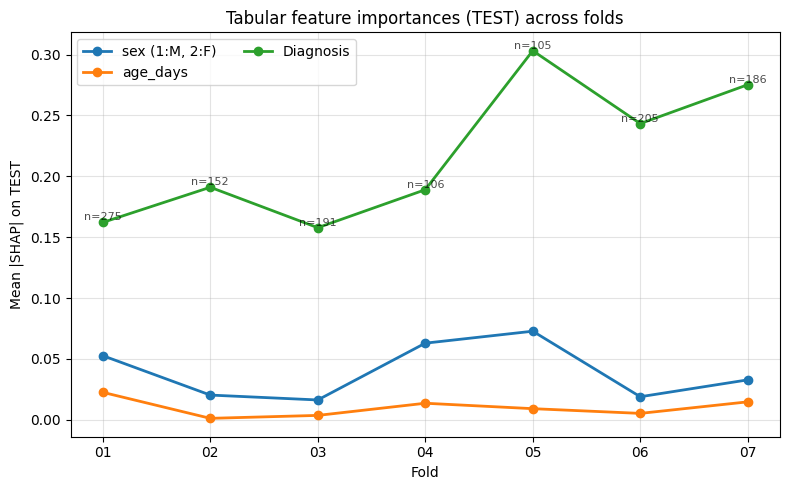

In [ ]:
# ========= FOUR FEATURE importances over TEST sets only =========
# Requires: FEAT_COLS, save_dir_path (Path(save_dir)), K_FOLDS,
#           _build_arrays, _get_bg_files, _compute_tab_shap_in_batches, _extract_tab_shap_2d,
#           BACKGROUND_N, SHAP_BATCH already defined; keras + shap available.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
import shap

# 1) Choose your four targets (use substrings; exact matches preferred)
TARGET_FEATURES = ["sex", "age", "diagnosis"]

feat_lower = [c.lower() for c in FEAT_COLS]

def _find_feature_idx(name):
    nl = name.lower()
    # exact (case-insensitive)
    if nl in feat_lower:
        i = feat_lower.index(nl)
        return i, FEAT_COLS[i]
    # substring fallback
    cands = [i for i, c in enumerate(feat_lower) if nl in c]
    if len(cands) == 0:
        raise ValueError(f"Feature '{name}' not found in FEAT_COLS={FEAT_COLS}")
    if len(cands) == 1:
        i = cands[0]
    else:
        # pick the shortest name among candidates
        i = min(cands, key=lambda k: len(FEAT_COLS[k]))
    return i, FEAT_COLS[i]

# Map the 4 features → indices & canonical labels
feat_map = [ _find_feature_idx(nm) for nm in TARGET_FEATURES ]
feat_indices = [i for i, _ in feat_map]
feat_labels  = [lab for _, lab in feat_map]

four_feat_results = {
    "feature_labels": feat_labels,
    "feature_indices": {lab: idx for idx, lab in zip(feat_indices, feat_labels)},
    "per_fold": {},               # fold_xx -> {lab: importance, n_test, engine}
    "overall_weighted_mean": {},  # lab -> weighted mean
}

# For overall weighted mean across all TEST samples from all folds
sum_abs_overall = np.zeros(len(FEAT_COLS), dtype=float)
n_test_overall  = 0

# For plotting
per_feature_series = {lab: [] for lab in feat_labels}
fold_ids, ns = [], []

for fold_idx in range(1, K_FOLDS + 1):
    fold_dir    = save_dir_path / f"fold_{fold_idx:02d}"
    weights_fp  = fold_dir / f"best_fold_{fold_idx:02d}.h5"
    test_list   = fold_dir / "test_files.txt"
    train_list  = fold_dir / "train_files.txt"
    val_list    = fold_dir / "val_files.txt"

    if not (weights_fp.exists() and test_list.exists() and train_list.exists()):
        print(f"(Fold {fold_idx:02d}) Missing weights/test/train lists; skipping.")
        continue

    # Files
    test_files  = [Path(x) for x in test_list.read_text().splitlines()  if x.strip()]
    train_files = [Path(x) for x in train_list.read_text().splitlines() if x.strip()]
    val_files   = [Path(x) for x in (val_list.read_text().splitlines() if val_list.exists() else []) if x.strip()]
    if len(test_files) == 0:
        print(f"(Fold {fold_idx:02d}) Empty test set; skipping.")
        continue

    # Arrays
    X_img_test, X_tab_test, _ = _build_arrays(test_files)
    bg_files = _get_bg_files(train_files, val_files, k=BACKGROUND_N)
    X_img_bg,  X_tab_bg,  _ = _build_arrays(bg_files)

    # Model & SHAP explainer
    model = keras.models.load_model(str(weights_fp))
    engine = None
    try:
        explainer = shap.DeepExplainer(model, [X_img_bg, X_tab_bg])
        _ = explainer.shap_values([X_img_test[:1], X_tab_test[:1]], check_additivity=False)
        engine = "DeepExplainer"
    except Exception:
        try:
            explainer = shap.GradientExplainer(model, data=[X_img_bg, X_tab_bg])
            _ = explainer.shap_values([X_img_test[:1], X_tab_test[:1]], check_additivity=False)
            engine = "GradientExplainer"
        except Exception:
            explainer = shap.Explainer(model, masker=[X_img_bg, X_tab_bg])
            _ = explainer([X_img_test[:1], X_tab_test[:1]])
            engine = "Explainer"

    # SHAP for tabular on TEST -> (N, D)
    if engine == "Explainer":
        exp = explainer([X_img_test, X_tab_test])  # Explanation
        shap_tab = _extract_tab_shap_2d([exp.values[0], exp.values[1]], feat_dim_expected=len(FEAT_COLS))
    else:
        shap_tab = _compute_tab_shap_in_batches(explainer, X_img_test, X_tab_test, batch=SHAP_BATCH)

    # Fold mean |SHAP| per feature
    mean_abs = np.mean(np.abs(shap_tab), axis=0)  # (D,)

    # Accumulate for weighted overall mean
    sum_abs_overall += np.sum(np.abs(shap_tab), axis=0)
    n_test_overall  += shap_tab.shape[0]

    # Record this fold
    rec = {"n_test": int(shap_tab.shape[0]), "engine": engine}
    for lab, idx in zip(feat_labels, feat_indices):
        rec[lab] = float(mean_abs[idx])
        per_feature_series[lab].append(float(mean_abs[idx]))
    four_feat_results["per_fold"][f"fold_{fold_idx:02d}"] = rec

    fold_ids.append(fold_idx)
    ns.append(int(shap_tab.shape[0]))

# Overall weighted mean across all TEST samples
if n_test_overall > 0:
    overall_mean = (sum_abs_overall / n_test_overall)
    four_feat_results["overall_weighted_mean"] = {
        lab: float(overall_mean[idx]) for lab, idx in zip(feat_labels, feat_indices)
    }
    four_feat_results["overall_weighted_mean"]["total_test_samples"] = int(n_test_overall)
else:
    print("No test samples found across folds; overall mean not computed.")

# Build a tidy table (features x folds + mean)
if four_feat_results["per_fold"]:
    # Assemble DataFrame with folds as columns
    df_list = []
    for f in sorted(four_feat_results["per_fold"].keys()):
        r = four_feat_results["per_fold"][f]
        df_list.append(pd.Series({lab: r[lab] for lab in feat_labels}, name=f))
    imp_table = pd.concat(df_list, axis=1)
    imp_table["mean_over_folds"] = imp_table.mean(axis=1)
    print("\n=== Four tabular features — mean(|SHAP|) on TEST by fold ===")
    with pd.option_context('display.float_format', '{:.6f}'.format):
        print(imp_table.sort_values("mean_over_folds", ascending=False).to_string())
else:
    print("\nNo folds recorded.")

# Quick line plot across folds (all four features)
if fold_ids:
    plt.figure(figsize=(8, 5))
    for lab in feat_labels:
        plt.plot(fold_ids, per_feature_series[lab], marker='o', linewidth=2, label=lab)
    for x, n in zip(fold_ids, ns):
        plt.text(x, max(v[x-1] for v in per_feature_series.values()), f"n={n}", fontsize=8,
                 ha='center', va='bottom', alpha=0.7)
    plt.xticks(fold_ids, [f"{f:02d}" for f in fold_ids])
    plt.xlabel("Fold")
    plt.ylabel("Mean |SHAP| on TEST")
    plt.title("Tabular feature importances (TEST) across folds")
    plt.grid(True, alpha=0.35)
    plt.legend(frameon=True, ncol=2)
    plt.tight_layout()
    plt.show()

# `four_feat_results` holds: indices/labels, per_fold dict, and overall weighted mean.


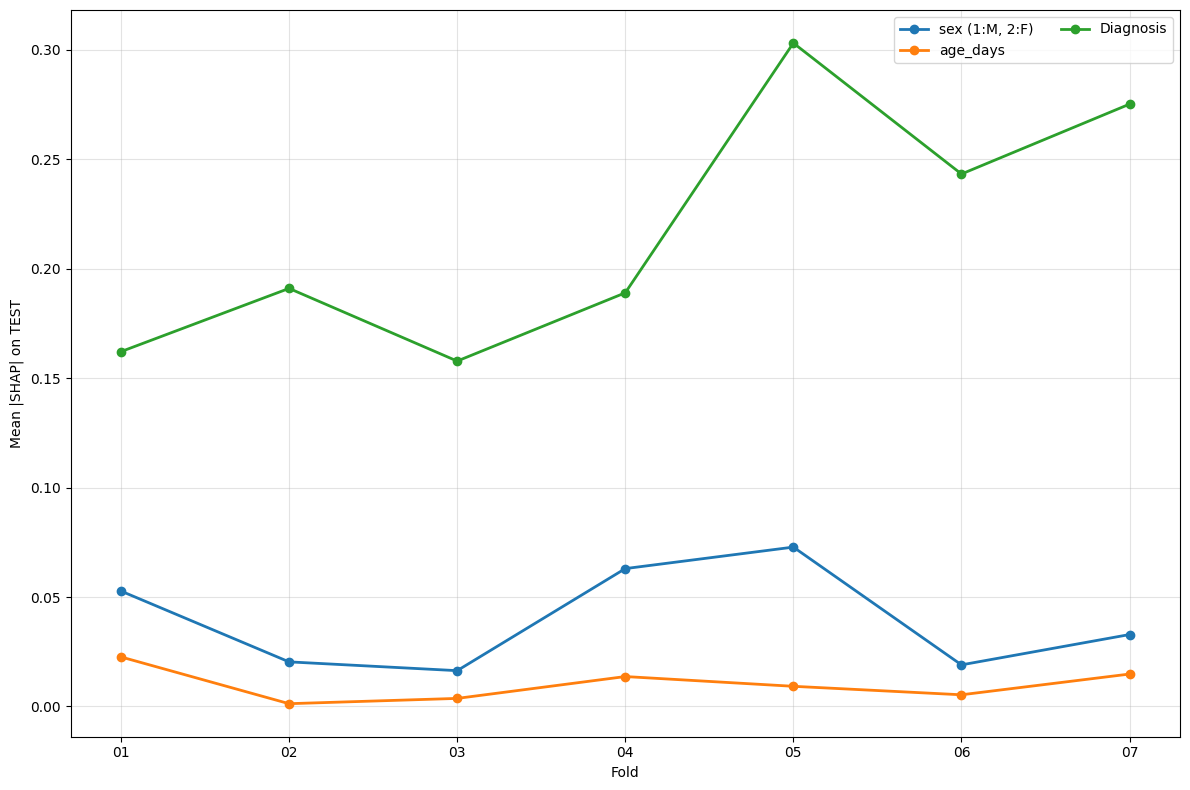

In [ ]:
if fold_ids:
    plt.figure(figsize=(12, 8))
    for lab in feat_labels:
        plt.plot(fold_ids, per_feature_series[lab], marker='o', linewidth=2, label=lab)
    plt.xticks(fold_ids, [f"{f:02d}" for f in fold_ids])
    plt.xlabel("Fold")
    plt.ylabel("Mean |SHAP| on TEST")
    plt.grid(True, alpha=0.35)
    plt.legend(frameon=True, ncol=2)
    plt.tight_layout()
    plt.show()

In [ ]:
bf_path = '/content/drive/MyDrive/ALL_CLEAN_DEIDEN_NAME AND ECMO DATA(Sheet1) (1) (version 2).csv'
cols = ['ID','age_days', 'Diagnosis', 'sex (1:M, 2:F)']
df = pd.read_csv(bf_path, usecols=cols)

s = pd.to_numeric(df['age_days'], errors='coerce')
df['age_days'] = pd.cut(s, [0,10,100,1000,np.inf], labels=[0,1,2,3],
                        include_lowest=True).astype('Int64')
for col in ['age_days']:
    s = pd.to_numeric(df[col], errors='coerce')
    mx = s.max(skipna=True)
    if pd.notna(mx) and mx != 0:
        df[col] = s / (mx*2)
    else:
        df[col] = s

diag_clean = (
    df['Diagnosis']
      .astype('string')
      .str.strip()
      .str.replace(r'\s+', ' ', regex=True)
      .fillna('Unknown')
)

codes, uniques = pd.factorize(diag_clean, sort=True)
df['Diagnosis'] = codes.astype('int64')
diagnosis_mapping = {cat: int(i) for i, cat in enumerate(uniques)}

In [ ]:
df[32: 50]

,ID,"sex (1:M, 2:F)",age_days,Diagnosis
32,36,2,0.0,2
33,37,2,0.333333,1
34,38,1,0.0,3
35,39,1,0.0,1
36,40,1,0.0,2
37,42,1,0.0,2
38,43,2,0.5,4
39,44,2,0.5,0
40,45,1,0.333333,1
41,46,1,0.166667,2


In [ ]:
#0: Cardiac Arrest
#1: Cardiogenic Shock
#2: Respiratory Failure
#3: Sepsis
#4: Septic shock

/tmp/ipython-input-1768496875.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("viridis")
/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


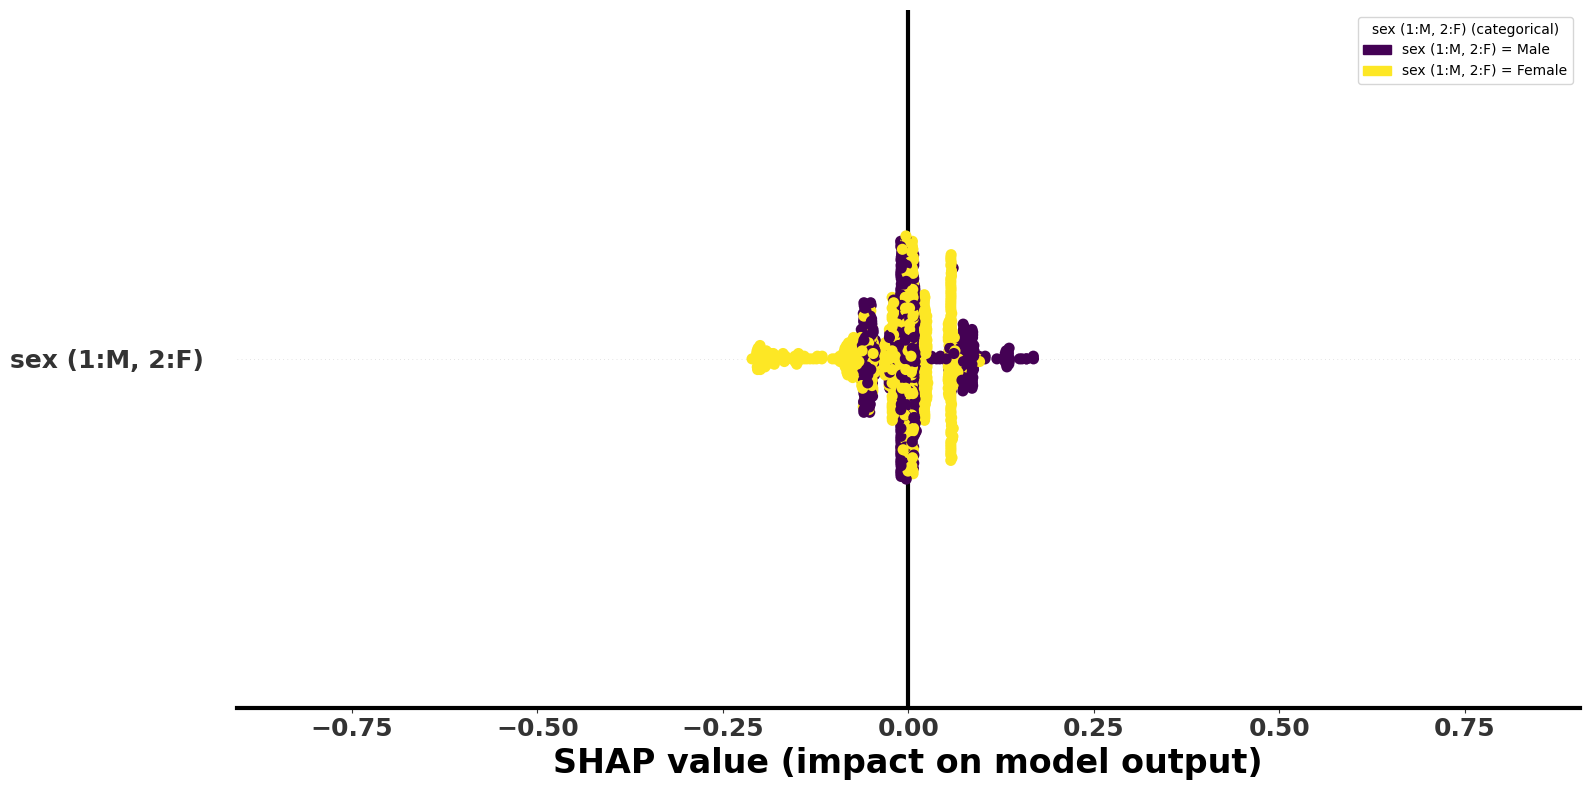

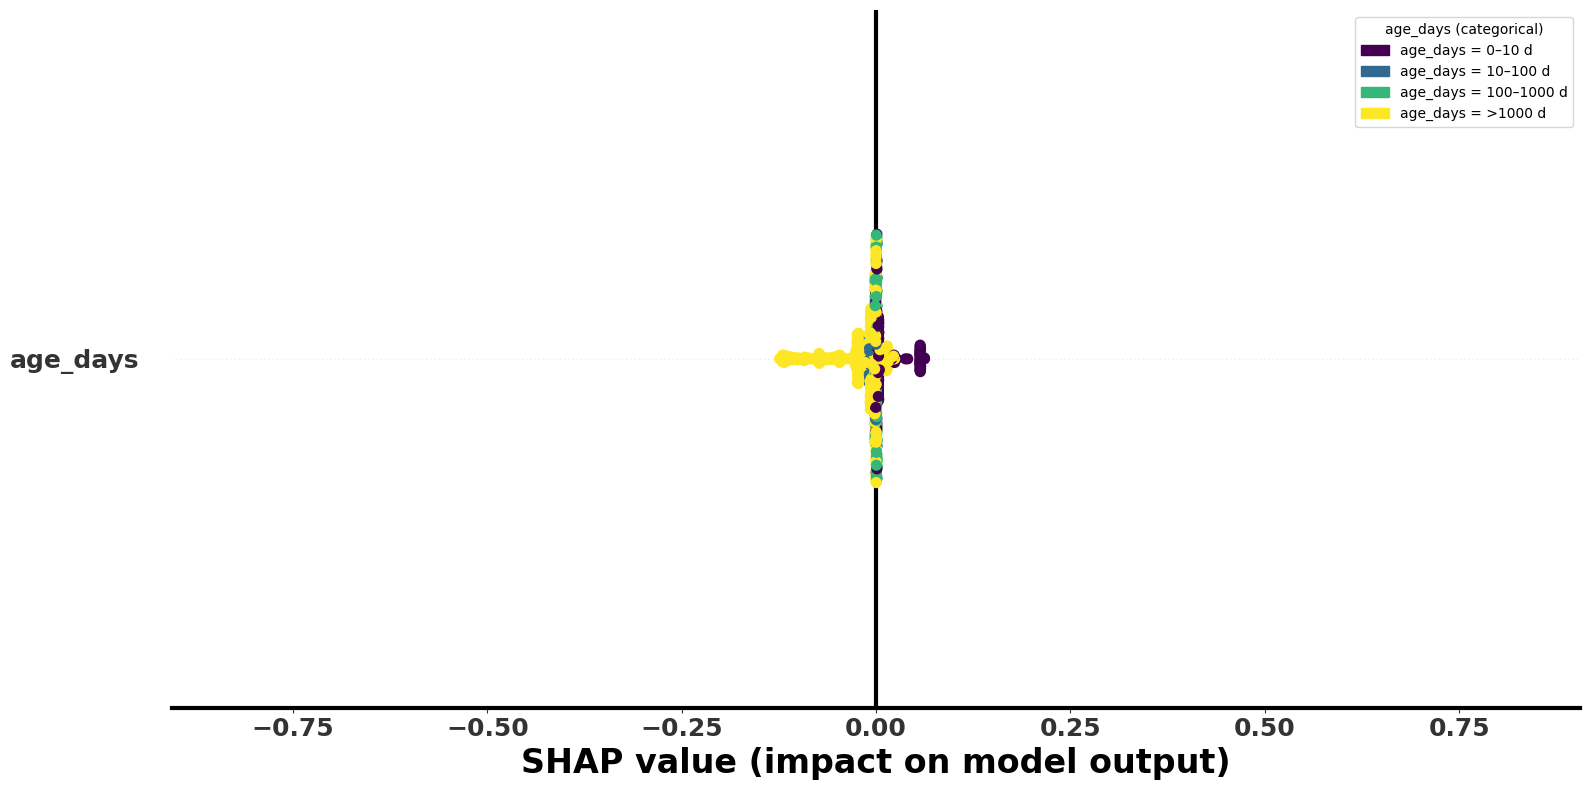

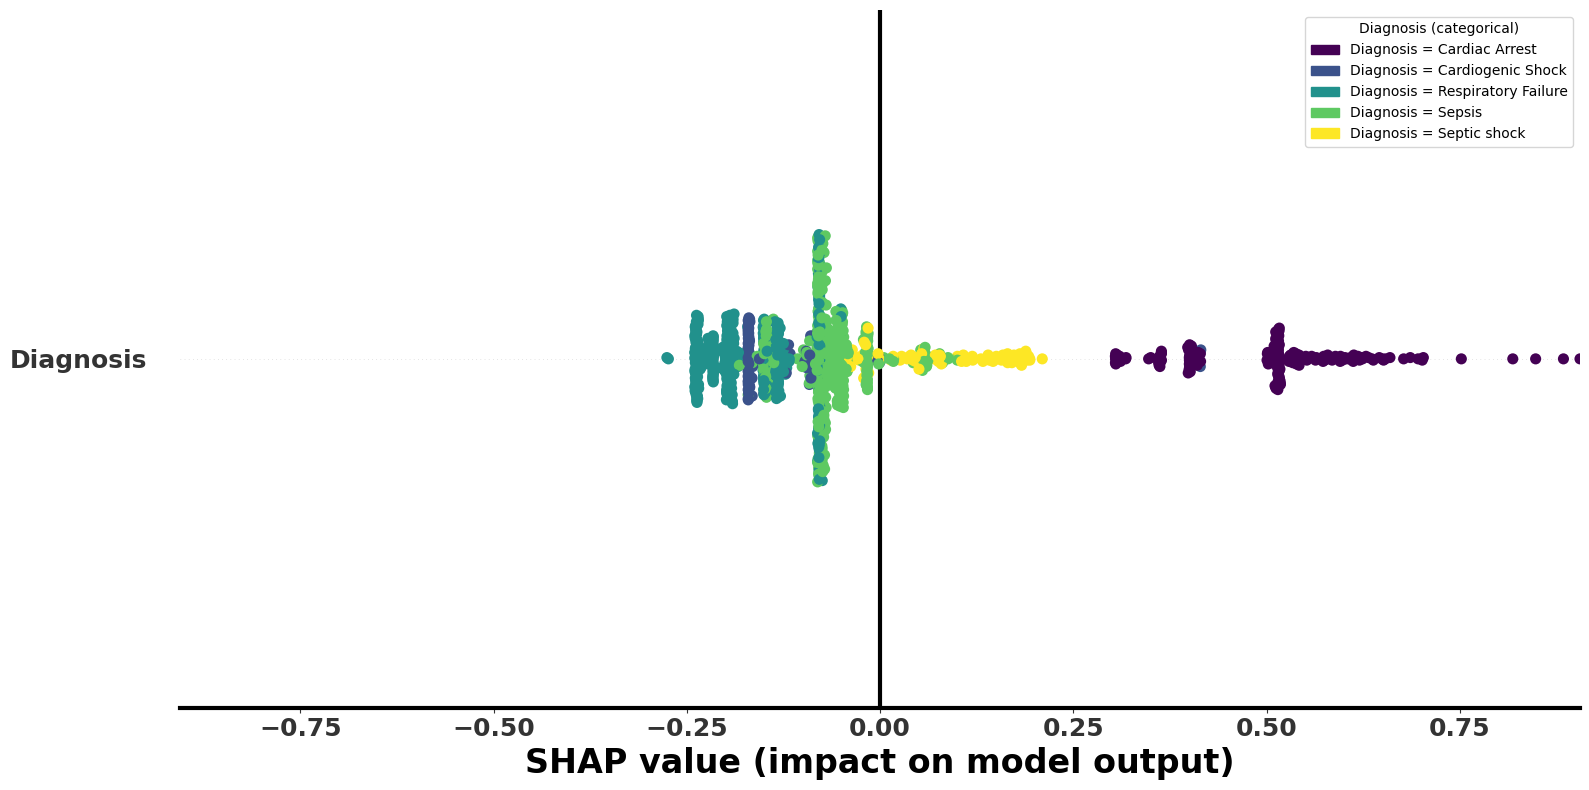

In [ ]:
# ===================== Beeswarm plots for four categorical tabular features (with legends) =====================
# REQUIRES already defined in your session:
#   save_dir_path = Path(save_dir)
#   FEAT_COLS, K_FOLDS, BACKGROUND_N, SHAP_BATCH
#   _build_arrays, _get_bg_files, _compute_tab_shap_in_batches, _extract_tab_shap_2d
#   keras, shap, matplotlib imported

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap
from tensorflow import keras
import shap

# -------- Target features (match by substring; case-insensitive) --------
TARGET_FEATURES = ["sex", "age", "diagnosis"]

# -------- Pretty text for legends --------
AGE_LABELS = {
    0: "0–10 d",
    1: "10–100 d",
    2: "100–1000 d",
    3: ">1000 d",
}
DIAGNOSIS_LABELS = {
    0: "Cardiac Arrest",
    1: "Cardiogenic Shock",
    2: "Respiratory Failure",
    3: "Sepsis",
    4: "Septic shock",
}
# Optional (edit if you have exact encodings)
SEX_LABELS = {1: "Male", 2: "Female"}
ETHNICITY_LABELS = {}  # leave empty to show raw codes; fill if you have a mapping

LABEL_MAPS = {
    "sex": SEX_LABELS,
    "age": AGE_LABELS,
    "diagnosis": DIAGNOSIS_LABELS,
    "ethnicity": ETHNICITY_LABELS,
}

# -------- Locate feature indices & canonical labels --------
feat_lower = [c.lower() for c in FEAT_COLS]

def _find_feature_idx(name):
    nl = name.lower()
    if nl in feat_lower:
        i = feat_lower.index(nl); return i, FEAT_COLS[i]
    cands = [i for i, c in enumerate(feat_lower) if nl in c]
    if not cands:
        raise ValueError(f"Feature '{name}' not found in FEAT_COLS={FEAT_COLS}")
    i = cands[0] if len(cands) == 1 else min(cands, key=lambda k: len(FEAT_COLS[k]))
    return i, FEAT_COLS[i]

feat_map     = [_find_feature_idx(nm) for nm in TARGET_FEATURES]
feat_indices = [i for i, _ in feat_map]
feat_labels  = [lab for _, lab in feat_map]  # actual column names in your features

# -------- Gather SHAP & feature data across folds --------
cmap = get_cmap("viridis")
shap_by_feat = {lab: [] for lab in feat_labels}
data_by_feat = {lab: [] for lab in feat_labels}

for fold_idx in range(1, K_FOLDS + 1):
    fold_dir    = save_dir_path / f"fold_{fold_idx:02d}"
    weights_fp  = fold_dir / f"best_fold_{fold_idx:02d}.h5"
    test_list   = fold_dir / "test_files.txt"
    train_list  = fold_dir / "train_files.txt"
    val_list    = fold_dir / "val_files.txt"

    if not (weights_fp.exists() and test_list.exists() and train_list.exists()):
        continue

    test_files  = [Path(x) for x in test_list.read_text().splitlines()  if x.strip()]
    if not test_files:
        continue
    train_files = [Path(x) for x in train_list.read_text().splitlines() if x.strip()]
    val_files   = [Path(x) for x in (val_list.read_text().splitlines() if val_list.exists() else []) if x.strip()]

    X_img_test, X_tab_test, _ = _build_arrays(test_files)
    bg_files = _get_bg_files(train_files, val_files, k=BACKGROUND_N)
    X_img_bg,  X_tab_bg,  _ = _build_arrays(bg_files)

    model = keras.models.load_model(str(weights_fp))
    # Explainer selection
    try:
        explainer = shap.DeepExplainer(model, [X_img_bg, X_tab_bg])
        _ = explainer.shap_values([X_img_test[:1], X_tab_test[:1]], check_additivity=False)
        engine = "DeepExplainer"
    except Exception:
        try:
            explainer = shap.GradientExplainer(model, data=[X_img_bg, X_tab_bg])
            _ = explainer.shap_values([X_img_test[:1], X_tab_test[:1]], check_additivity=False)
            engine = "GradientExplainer"
        except Exception:
            explainer = shap.Explainer(model, masker=[X_img_bg, X_tab_bg])
            _ = explainer([X_img_test[:1], X_tab_test[:1]])
            engine = "Explainer"

    # SHAP for tabular -> (N, D)
    if engine == "Explainer":
        exp = explainer([X_img_test, X_tab_test])
        shap_tab = _extract_tab_shap_2d([exp.values[0], exp.values[1]], feat_dim_expected=len(FEAT_COLS))
    else:
        shap_tab = _compute_tab_shap_in_batches(explainer, X_img_test, X_tab_test, batch=SHAP_BATCH)

    # keep only the 4 features (as (N,1) for SHAP's Explanation API)
    for lab, idx in zip(feat_labels, feat_indices):
        vals = shap_tab[:, idx:idx+1]      # (N,1)
        dat  = X_tab_test[:, idx:idx+1]    # (N,1)
        shap_by_feat[lab].append(vals)
        data_by_feat[lab].append(dat)

# Concatenate across folds and coerce categories to integer codes
for lab in feat_labels:
    if shap_by_feat[lab]:
        shap_by_feat[lab] = np.vstack(shap_by_feat[lab])   # (M,1)
        dat = np.vstack(data_by_feat[lab]).astype(float)   # (M,1)

        # Robust coercion to int category codes (fixes cases like 0, 1/6, 2/6, 3/6 for binned age)
        # If values seem in (0..1) with ~4 unique bins, map to {0,1,2,3} via *6 & round, then clip.
        uniq = np.unique(dat[~np.isnan(dat)])
        if len(uniq) <= 6 and np.nanmax(dat) <= 1.01 and np.nanmin(dat) >= -0.01:
            dat_codes = np.rint(dat * 6).astype(int)
            dat_codes = np.clip(dat_codes, 0, 9)  # broad clip
        else:
            dat_codes = np.rint(dat).astype(int)

        data_by_feat[lab] = dat_codes
    else:
        shap_by_feat[lab] = np.zeros((0,1), dtype=float)
        data_by_feat[lab] = np.zeros((0,1), dtype=int)

# -------- Styling helpers --------
W, H = 16, 8
POINT_SCALE = 4.0
LABEL_FS = 24
TICK_FS  = 18
SPINE_W  = 3.0
ZERO_W   = 3.0

def scale_beeswarm_points(ax, scale=POINT_SCALE):
    for col in ax.collections:
        try:
            col.set_sizes(col.get_sizes() * scale)
        except Exception:
            pass

def style_axes(ax, xlabel=None, xlim=None):
    if xlim is not None:
        ax.set_xlim(*xlim)
    for t in ax.get_xticklabels():
        t.set_fontsize(TICK_FS); t.set_fontweight("bold")
    for t in ax.get_yticklabels():
        t.set_fontsize(TICK_FS); t.set_fontweight("bold")
    for s in ax.spines.values():
        s.set_linewidth(SPINE_W); s.set_color("black")
    ax.axvline(0, color="black", linewidth=ZERO_W)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FS, fontweight="bold")

# Common symmetric x-limits across features
all_vals = np.concatenate([np.asarray(shap_by_feat[lab]).ravel() for lab in feat_labels]) if feat_labels else np.array([0.0])
x_abs = float(np.nanmax(np.abs(all_vals))) if all_vals.size else 1.0
xlim = (-x_abs, x_abs)

# -------- Plot one beeswarm per (categorical) feature --------
for lab in feat_labels:
    vals = shap_by_feat[lab]
    dat  = data_by_feat[lab]
    if vals.size == 0:
        print(f"(skip) No SHAP values for {lab}.")
        continue

    # SHAP Explanation for a single feature
    exp = shap.Explanation(values=vals, data=dat, feature_names=[lab])

    # Figure
    try:
        shap.plots.beeswarm(exp, max_display=1, color=cmap, color_bar=False, show=False, plot_size=(W, H))
    except TypeError:
        shap.plots.beeswarm(exp, max_display=1, color=cmap, color_bar=False, show=False)
    fig = plt.gcf(); ax = plt.gca(); fig.set_size_inches(W, H, forward=True)
    scale_beeswarm_points(ax)

    # Legend — use pretty labels when we have them
    lab_key = None
    ll = lab.lower()
    for key in LABEL_MAPS.keys():
        if key in ll:
            lab_key = key; break

    cats = np.unique(dat.ravel()[~np.isnan(dat.ravel())]).astype(int)
    vmin, vmax = cats.min(), cats.max()
    norm = Normalize(vmin=vmin, vmax=vmax)

    handles = []
    label_dict = LABEL_MAPS.get(lab_key, {})
    for code in sorted(cats):
        text = label_dict.get(int(code), str(int(code)))
        color = cmap(norm(code))
        handles.append(mpatches.Patch(color=color, label=f"{lab} = {text}"))

    ax.legend(handles=handles, title=f"{lab} (categorical)", loc="upper right", frameon=True)

    style_axes(ax, xlabel="SHAP value (impact on model output)", xlim=xlim)
    plt.tight_layout(); plt.show()


In [ ]:
import numpy as np
import pandas as pd

# Keep your label maps (edit if needed)
AGE_LABELS = {0: "0–10 d", 1: "10–100 d", 2: "100–1000 d", 3: ">1000 d"}
DIAGNOSIS_LABELS = {
    0: "Cardiac Arrest",
    1: "Cardiogenic Shock",
    2: "Respiratory Failure",
    3: "Sepsis",
    4: "Septic shock",
}

ETHNICITY_LABELS = {}                   # fill if you have codes

LABEL_MAPS = {
    "age": AGE_LABELS,
    "diagnosis": DIAGNOSIS_LABELS,
    "sex": SEX_LABELS,
    "ethnicity": ETHNICITY_LABELS,
}

def _label_for(feature_name_lower: str, code: int) -> str:
    for key, mapping in LABEL_MAPS.items():
        if key in feature_name_lower and code in mapping:
            return mapping[code]
    return str(int(code))

def _coerce_to_int_codes(dat_1d: np.ndarray) -> np.ndarray:
    """Coerce category values to integer codes (handles scaled bins like 0, 1/6, 2/6, ...)."""
    x = np.asarray(dat_1d, dtype=float)
    x = x[~np.isnan(x)]
    if x.size == 0:
        return np.array([], dtype=int)
    uniq = np.unique(x)
    # Heuristic: if values look like small fractions (0..~1), map by *6 and round
    if (len(uniq) <= 6) and (np.nanmax(x) <= 1.01) and (np.nanmin(x) >= -0.01):
        codes = np.rint(x * 6).astype(int)
        codes = np.clip(codes, 0, 999)
    else:
        codes = np.rint(x).astype(int)
    return codes

def _fmt_signed(x: float) -> str:
    return f"{x:+.6f}"

# ----- Build and print four signed tables -----
if 'shap_by_feat' not in globals() or 'data_by_feat' not in globals() or 'feat_labels' not in globals():
    raise RuntimeError("Expected shap_by_feat, data_by_feat, and feat_labels from the previous step.")

tables_by_feature_signed = {}

for lab in feat_labels:
    vals = shap_by_feat[lab]    # (M,1)
    dat  = data_by_feat[lab]    # (M,1)
    if vals.size == 0:
        print(f"(skip) No SHAP values for {lab}.")
        continue

    v = np.asarray(vals, dtype=float).ravel()
    d_raw = np.asarray(dat).ravel().astype(float)

    # Drop NaNs
    mask_valid = ~np.isnan(v) & ~np.isnan(d_raw)
    v = v[mask_valid]
    d_raw = d_raw[mask_valid]

    # Category codes
    d_codes = _coerce_to_int_codes(d_raw)

    rows = []
    for code in sorted(np.unique(d_codes)):
        m = (d_codes == code)
        if not np.any(m):
            continue
        # SIGNED mean SHAP (directional)
        mean_signed = float(np.mean(v[m]))
        # Absolute (for reference)
        mean_abs = float(np.mean(np.abs(v[m])))

        rows.append({
            "category_code": int(code),
            "category_label": _label_for(lab.lower(), int(code)),
            "n": int(m.sum()),
            "mean_SHAP_signed": mean_signed,
            "mean_SHAP_signed_str": _fmt_signed(mean_signed),
            "mean_abs_SHAP": mean_abs,
        })

    # Overall (signed + abs)
    overall_signed = float(np.mean(v)) if v.size else np.nan
    overall_abs    = float(np.mean(np.abs(v))) if v.size else np.nan

    df_feat = pd.DataFrame(rows).sort_values(["category_code"]).reset_index(drop=True)
    df_feat.loc[len(df_feat)] = {
        "category_code": -1,
        "category_label": "OVERALL",
        "n": int(v.size),
        "mean_SHAP_signed": overall_signed,
        "mean_SHAP_signed_str": _fmt_signed(overall_signed),
        "mean_abs_SHAP": overall_abs,
    }

    tables_by_feature_signed[lab] = df_feat

# Pretty print
for lab, tab in tables_by_feature_signed.items():
    print("\n" + "="*12 + f" {lab} (SIGNED SHAP) " + "="*12)
    # Show the signed string column to force +/– in the console
    with pd.option_context('display.float_format', '{:.6f}'.format):
        print(tab[["category_code","category_label","n","mean_SHAP_signed","mean_SHAP_signed_str","mean_abs_SHAP"]]
              .to_string(index=False))



============ sex (1:M, 2:F) (SIGNED SHAP) ============
 category_code category_label    n  mean_SHAP_signed mean_SHAP_signed_str  mean_abs_SHAP
             1           Male  530          0.003270            +0.003270       0.036582
             2         Female  690         -0.017705            -0.017705       0.047526
            -1        OVERALL 1220         -0.008593            -0.008593       0.042771

============ age_days (SIGNED SHAP) ============
 category_code category_label    n  mean_SHAP_signed mean_SHAP_signed_str  mean_abs_SHAP
             0         0–10 d  216          0.012851            +0.012851       0.012958
             1       10–100 d   61         -0.005506            -0.005506       0.005506
             2     100–1000 d  171          0.000257            +0.000257       0.000728
             3        >1000 d  772         -0.019367            -0.019367       0.021700
            -1        OVERALL 1220         -0.010219            -0.010219       0.016403

===

In [ ]:
tables_by_feature_signed

{'sex (1:M, 2:F)':    category_code category_label     n  mean_SHAP_signed mean_SHAP_signed_str  \
 0              1           Male   530          0.003270            +0.003270   
 1              2         Female   690         -0.017705            -0.017705   
 2             -1        OVERALL  1220         -0.008593            -0.008593   
 
    mean_abs_SHAP  
 0       0.036582  
 1       0.047526  
 2       0.042771  ,
 'age_days':    category_code category_label     n  mean_SHAP_signed mean_SHAP_signed_str  \
 0              0         0–10 d   216          0.012851            +0.012851   
 1              1       10–100 d    61         -0.005506            -0.005506   
 2              2     100–1000 d   171          0.000257            +0.000257   
 3              3        >1000 d   772         -0.019367            -0.019367   
 4             -1        OVERALL  1220         -0.010219            -0.010219   
 
    mean_abs_SHAP  
 0       0.012958  
 1       0.005506  
 2       0.0007

### check the EEG importances

In [ ]:
from pathlib import Path
import numpy as np
import shap
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
def compute_eeg_shap_per_sample(save_dir: str,
                                fold_to_run: int = 1,
                                background_n: int = 64):
    """
    Compute EEG SHAP maps per test sample for a given fold.
    Inputs
    ------
    save_dir:       directory that contains fold_{XX}/ with weights & split files
    fold_to_run:    which fold to load (1-based)
    background_n:   number of (train+val) examples used as SHAP background

    Returns
    -------
    shapN : np.ndarray, shape (N, H, W, 1)   # SHAP for class N per test sample
    shapY : np.ndarray, shape (N, H, W, 1)   # SHAP for class Y per test sample
    info  : dict with keys:
        - engine: str  (which SHAP explainer was used)
        - H, W, C
        - X_img_test, X_tab_test  (for optional plotting)
        - test_files, bg_files
    """


    # ---------- helpers (use your existing loaders/globals) ----------
    rng = np.random.default_rng(1)

    def _pick_bg_files(train_files, val_files, k):
        pool = list(train_files) + list(val_files)
        if not pool:
            pool = list(train_files)
        if not pool:
            raise RuntimeError("No background data for SHAP (train+val empty).")
        k = min(k, len(pool))
        idx = rng.choice(len(pool), size=k, replace=False)
        return [pool[i] for i in idx]

    def _build_arrays(file_list, H=None, W=None):
        """Return (X_img, X_tab, H, W) using load_csv_as_image_cached + ID_TO_FEAT."""
        img0 = load_csv_as_image_cached(file_list[0])
        if img0.ndim == 2:
            img0 = img0[..., None]
        if H is None or W is None:
            H, W = img0.shape[0], img0.shape[1]

        tab_dim = len(next(iter(ID_TO_FEAT.values())))
        X_img = np.empty((len(file_list), H, W, 1), dtype=np.float32)
        X_tab = np.empty((len(file_list), tab_dim), dtype=np.float32)

        for i, f in enumerate(file_list):
            xi = load_csv_as_image_cached(f)
            if xi.ndim == 2:
                xi = xi[..., None]
            # pad/crop to (H, W)
            if xi.shape[:2] != (H, W):
                h, w = xi.shape[:2]
                buf = np.zeros((H, W, 1), dtype=xi.dtype)
                buf[:min(h, H), :min(w, W), 0] = xi[:min(h, H), :min(w, W), 0]
                xi = buf
            X_img[i] = xi
            pid = patient_num_from_path(f)
            X_tab[i] = ID_TO_FEAT[pid]
        return X_img, X_tab, H, W

    def _ensure_4d(x, H, W, C, select_class=None):
        """
        Normalize SHAP map to (1, H, W, C).
        Handles shapes like (H,W,C,2), (H,W,2), (1,H,W,C,2), (1,H,W,2), (H,W,C), (H,W), etc.
        If last dim==2 and select_class is not None, pick that class; else average over it.
        """
        x = np.asarray(x)
        # if final dim is the two classes [N,Y]
        if x.ndim >= 3 and x.shape[-1] == 2:
            x = x[..., select_class] if select_class is not None else x.mean(axis=-1)

        if x.ndim == 2 and x.shape == (H, W):
            x = x[..., None]
        if x.ndim == 3 and x.shape == (H, W, C):
            return x[None, ...]
        if x.ndim == 4 and x.shape[1:4] == (H, W, C):
            return x[:1]  # K==1
        # best-effort squeeze then fix
        x = np.squeeze(x)
        if x.ndim == 2 and x.shape == (H, W):
            return x[None, ..., None]
        if x.ndim == 3 and x.shape == (H, W, C):
            return x[None, ...]
        raise ValueError(f"Unexpected SHAP map shape {x.shape}")

    # ---------- locate fold files ----------
    fold_dir   = Path(save_dir) / f"fold_{fold_to_run:02d}"
    weights_fp = fold_dir / f"best_fold_{fold_to_run:02d}.h5"
    train_txt  = fold_dir / "train_files.txt"
    test_txt   = fold_dir / "test_files.txt"
    val_txt    = fold_dir / "val_files.txt"

    if not weights_fp.exists():
        raise FileNotFoundError(f"Missing weights: {weights_fp}")
    if not train_txt.exists() or not test_txt.exists():
        raise FileNotFoundError(f"Missing split lists in {fold_dir}")

    train_files = [Path(s) for s in train_txt.read_text().splitlines() if s.strip()]
    test_files  = [Path(s) for s in test_txt.read_text().splitlines() if s.strip()]
    val_files   = [Path(s) for s in (val_txt.read_text().splitlines() if val_txt.exists() else []) if s.strip()]
    if not test_files:
        raise RuntimeError("Empty test set.")

    # ---------- build background & test tensors ----------
    bg_files = _pick_bg_files(train_files, val_files, k=background_n)
    img0 = load_csv_as_image_cached(test_files[0])
    if img0.ndim == 2:
        img0 = img0[..., None]
    H, W, C = img0.shape[0], img0.shape[1], 1

    X_img_bg,  X_tab_bg,  H, W = _build_arrays(bg_files,  H, W)
    X_img_test, X_tab_test, _, _ = _build_arrays(test_files, H, W)

    print("X_img_bg.shape =", X_img_bg.shape)
    print("X_tab_bg.shape =", X_tab_bg.shape)
    print("X_img_test.shape =", X_img_test.shape)
    print("X_tab_test.shape =", X_tab_test.shape)

    # ---------- load model & set up SHAP explainer ----------
    base = keras.models.load_model(str(weights_fp))
    explainer = None
    two_output = False
    engine = None

    try:
        # build 2-output head: [pN, pY] = [1-pY, pY]
        p1 = base.output
        p0 = layers.Lambda(lambda t: 1.0 - t, name="p0")(p1)
        preds2 = layers.Concatenate(name="p0_p1")([p0, p1])
        twin = keras.Model(inputs=base.inputs, outputs=preds2)
        try:
            explainer = shap.DeepExplainer(twin, [X_img_bg, X_tab_bg])
            _ = explainer.shap_values([X_img_test[:1], X_tab_test[:1]], check_additivity=False)
            two_output = True
            engine = "DeepExplainer (two-output)"
        except Exception:
            explainer = shap.GradientExplainer(twin, data=[X_img_bg, X_tab_bg])
            _ = explainer.shap_values([X_img_test[:1], X_tab_test[:1]], check_additivity=False)
            two_output = True
            engine = "GradientExplainer (two-output)"
    except Exception:
        # fall back to single-output pY
        try:
            explainer = shap.DeepExplainer(base, [X_img_bg, X_tab_bg])
            engine = "DeepExplainer (single-output)"
        except Exception:
            try:
                explainer = shap.GradientExplainer(base, data=[X_img_bg, X_tab_bg])
                engine = "GradientExplainer (single-output)"
            except Exception:
                explainer = shap.Explainer(base, masker=[X_img_bg, X_tab_bg])
                engine = "Explainer (single-output)"

    print("SHAP engine:", engine)

    # ---------- per-sample SHAP ----------
    N = X_img_test.shape[0]
    shapN = np.zeros((N, H, W, 1), dtype=np.float32)
    shapY = np.zeros((N, H, W, 1), dtype=np.float32)

    for i in range(N):
        xi = X_img_test[i:i+1]   # (1,H,W,1)
        xt = X_tab_test[i:i+1]   # (1,D)
        sv = explainer.shap_values([xi, xt], check_additivity=False)

        if two_output:
            # expected: list over classes -> list over inputs
            if isinstance(sv, list) and len(sv) == 2 and isinstance(sv[0], list):
                eegN = sv[0][0]
                eegY = sv[1][0]
                eegN = _ensure_4d(eegN, H, W, 1, select_class=0)
                eegY = _ensure_4d(eegY, H, W, 1, select_class=1)
            else:
                # sometimes SHAP returns a single EEG array where last dim is classes
                eeg = sv[0] if isinstance(sv, list) else sv
                eegN = _ensure_4d(eeg, H, W, 1, select_class=0)
                eegY = _ensure_4d(eeg, H, W, 1, select_class=1)
            shapN[i] = eegN[0]
            shapY[i] = eegY[0]
        else:
            # single-output pY; N map is negative
            eegY = sv[0] if isinstance(sv, list) else sv
            eegY = _ensure_4d(eegY, H, W, 1, select_class=None)
            shapY[i] = eegY[0]
            shapN[i] = -eegY[0]

    print("Per-sample SHAP done:")
    print("  shapN:", shapN.shape)
    print("  shapY:", shapY.shape)

    info = dict(
        engine=engine, H=H, W=W, C=C,
        X_img_test=X_img_test, X_tab_test=X_tab_test,
        test_files=test_files, bg_files=bg_files
    )
    return shapN, shapY, info


In [ ]:
 shapN, shapY, info = compute_eeg_shap_per_sample(save_dir,
                                fold_to_run= 2,
                                background_n = 128)

X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 3)
X_img_test.shape = (152, 360, 6, 1)
X_tab_test.shape = (152, 3)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


SHAP engine: DeepExplainer (two-output)
Per-sample SHAP done:
  shapN: (152, 360, 6, 1)
  shapY: (152, 360, 6, 1)


In [ ]:
def plot_avg_eeg_shap(
    shapN=None, shapY=None,          # (N, time, channels, 1) — optional
    avgN=None, avgY=None,            # (time, channels) or (channels, time) — optional
    cell_x=0.070, cell_y=0.260,      # inches per time step / per channel
    cmap="RdBu_r",
    title_suffix=""
):
    """
    Plot two heatmaps (Avg SHAP — Y on top, Avg SHAP — N below) with a single
    vertical colorbar. Matches your layout; thickness/width set by cell_x/cell_y.

    Pass either shapN/shapY (per-sample SHAP, shape (N, time, channels, 1))
    or pre-averaged maps avgN/avgY (shape (time, channels) or (channels, time)).
    """

    # ----- prepare averages -----
    if avgN is None or avgY is None:
        if shapN is None or shapY is None:
            raise ValueError("Provide either shapN/shapY or avgN/avgY.")
        avgN = shapN.mean(axis=0)[..., 0]      # (time, channels)
        avgY = shapY.mean(axis=0)[..., 0]

    # infer time length & channels, and orient to (channels, time) for plotting
    def _orient_to_ct(mat):
        a = np.asarray(mat)
        h, w = a.shape[:2]
        # your data has time >> channels (e.g., 360 > 6)
        time_is_first = (h >= w)
        if time_is_first:   # (time, channels) -> (channels, time)
            return a.T, h, w
        else:               # (channels, time) -> already correct
            return a, w, h

    avgN_plot, tN, cN = _orient_to_ct(avgN)
    avgY_plot, tY, cY = _orient_to_ct(avgY)

    # sanity: use common dims
    time_len   = tN if tN == tY else max(tN, tY)
    n_channels = cN if cN == cY else max(cN, cY)

    # symmetric color scale across both panels
    vmax = float(max(np.abs(avgN_plot).max(), np.abs(avgY_plot).max())) + 1e-12

    # ----- size from "cell" knobs -----
    W = time_len * cell_x     # total inches for the x dimension
    H = n_channels * cell_y   # total inches for the y dimension

    fig = plt.figure(figsize=(W + 1.0, 2 * H + 0.8))
    gs  = fig.add_gridspec(
        nrows=2, ncols=2,
        width_ratios=[W, 0.7],          # thinner colorbar
        height_ratios=[H, H],
        wspace=0.25, hspace=0.35
    )

    axY = fig.add_subplot(gs[0, 0])
    axN = fig.add_subplot(gs[1, 0])
    cax = fig.add_subplot(gs[:, 1])

    # --- Y on top ---
    imY = axY.imshow(
        avgY_plot, origin="lower", cmap=cmap,
        vmin=-vmax, vmax=vmax,
        extent=[0, time_len, 0, n_channels],
        interpolation="nearest", aspect="auto"   # do not stretch; fill the axes
    )
    axY.set_title(f"Average SHAP — Y{(' ' + title_suffix) if title_suffix else ''}")
    axY.set_xlim(0, time_len); axY.set_ylim(0, n_channels)
    axY.set_xticks([0, time_len/3, 2*time_len/3, time_len])
    axY.set_yticks(list(range(1, n_channels + 1)))
    axY.set_ylabel("Channel")

    # --- N below ---
    imN = axN.imshow(
        avgN_plot, origin="lower", cmap=cmap,
        vmin=-vmax, vmax=vmax,
        extent=[0, time_len, 0, n_channels],
        interpolation="nearest", aspect="auto"
    )
    axN.set_title(f"Average SHAP — N{(' ' + title_suffix) if title_suffix else ''}")
    axN.set_xlim(0, time_len); axN.set_ylim(0, n_channels)
    axN.set_xticks([0, time_len/3, 2*time_len/3, time_len])
    axN.set_yticks(list(range(1, n_channels + 1)))
    axN.set_xlabel("Time")
    axN.set_ylabel("Channel")

    # shared vertical colorbar
    cb = fig.colorbar(imY, cax=cax, orientation="vertical")
    cb.set_label("SHAP value", rotation=90, labelpad=10)

    plt.tight_layout()
    plt.show()
    return fig, (axY, axN), cb

def compute_sum(shapY):
    A = np.abs(np.asarray(shapY, float))
    per_time = A.mean(axis=0)                # (T, C, 1)
    return per_time.sum(axis=(0, 2)).reshape(-1,1)         # -> (C,)

/tmp/ipython-input-2874357802.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


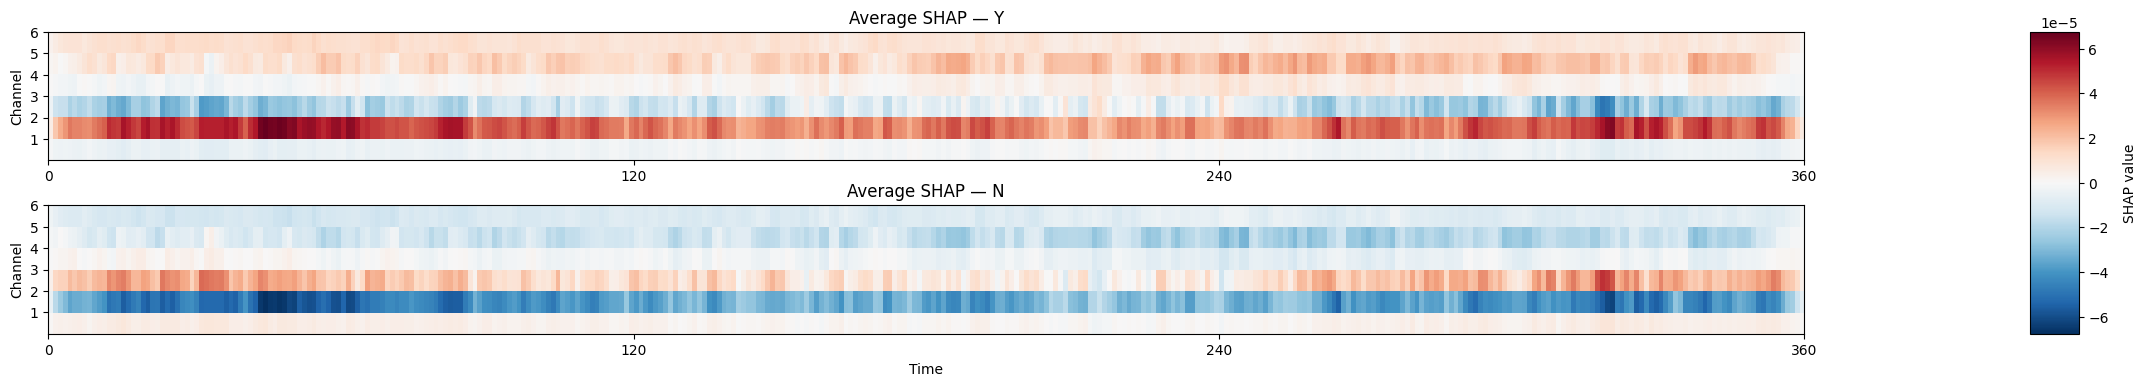

(<Figure size 2620x392 with 3 Axes>,
 (<Axes: title={'center': 'Average SHAP — Y'}, ylabel='Channel'>,
  <Axes: title={'center': 'Average SHAP — N'}, xlabel='Time', ylabel='Channel'>),
 <matplotlib.colorbar.Colorbar at 0x79491ccca840>)

In [ ]:
plot_avg_eeg_shap(shapN, shapY)

In [ ]:
shapY.shape

(152, 360, 6, 1)

### Compute 7 fold importances

X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 3)
X_img_test.shape = (275, 360, 6, 1)
X_tab_test.shape = (275, 3)
SHAP engine: DeepExplainer (two-output)
Per-sample SHAP done:
  shapN: (275, 360, 6, 1)
  shapY: (275, 360, 6, 1)


/tmp/ipython-input-2874357802.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


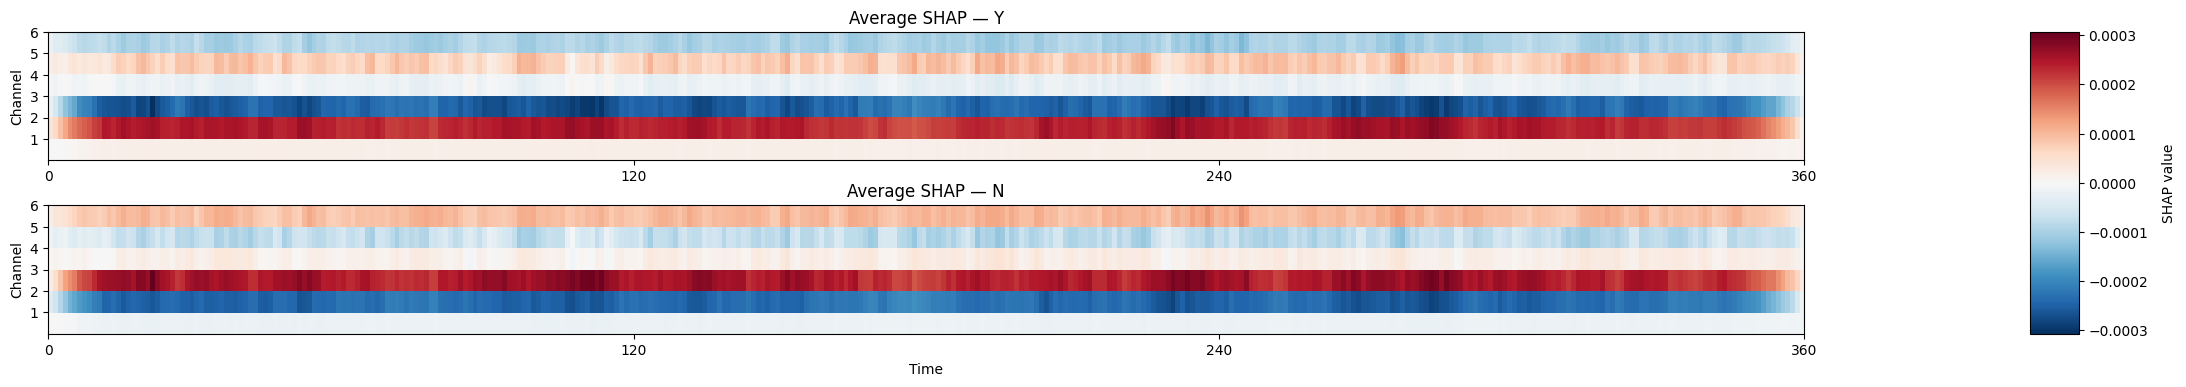

X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 3)
X_img_test.shape = (152, 360, 6, 1)
X_tab_test.shape = (152, 3)
SHAP engine: DeepExplainer (two-output)
Per-sample SHAP done:
  shapN: (152, 360, 6, 1)
  shapY: (152, 360, 6, 1)


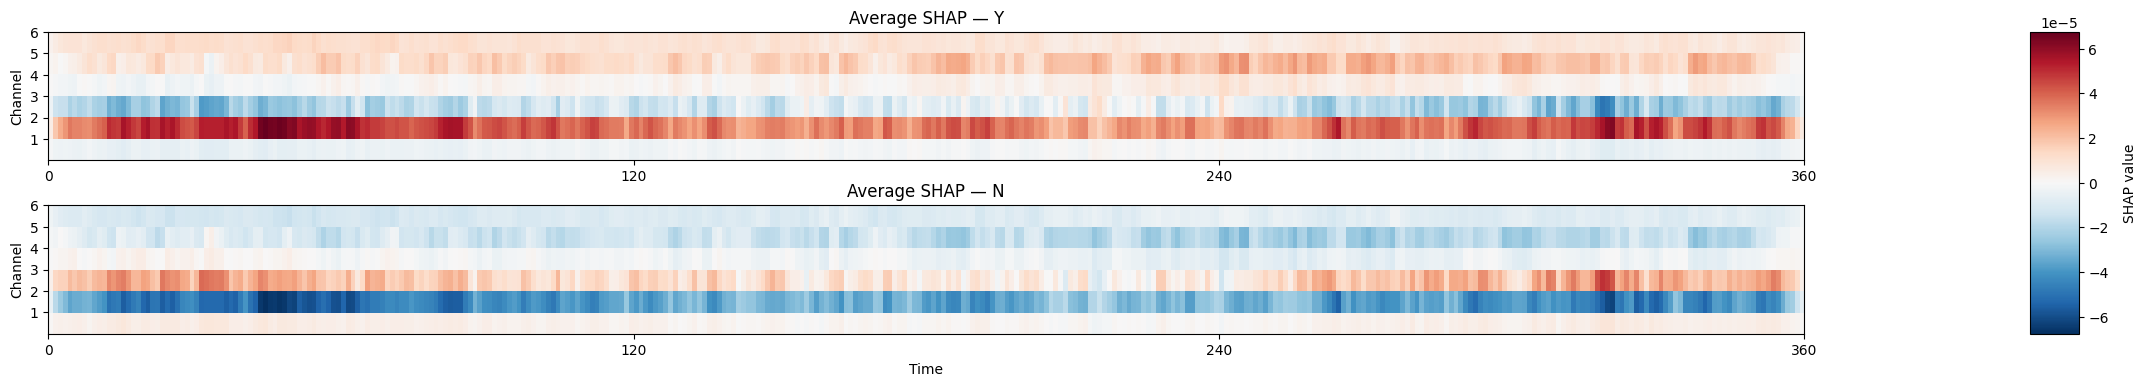

X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 3)
X_img_test.shape = (191, 360, 6, 1)
X_tab_test.shape = (191, 3)
SHAP engine: DeepExplainer (two-output)
Per-sample SHAP done:
  shapN: (191, 360, 6, 1)
  shapY: (191, 360, 6, 1)


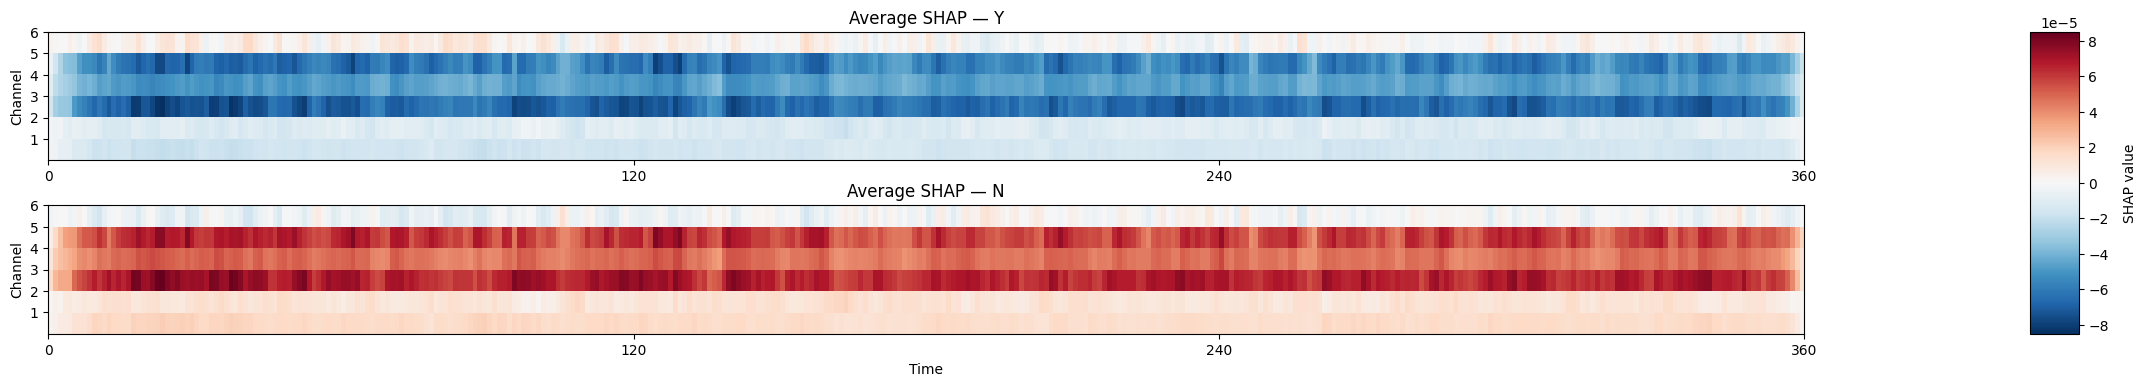

X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 3)
X_img_test.shape = (106, 360, 6, 1)
X_tab_test.shape = (106, 3)
SHAP engine: DeepExplainer (two-output)
Per-sample SHAP done:
  shapN: (106, 360, 6, 1)
  shapY: (106, 360, 6, 1)


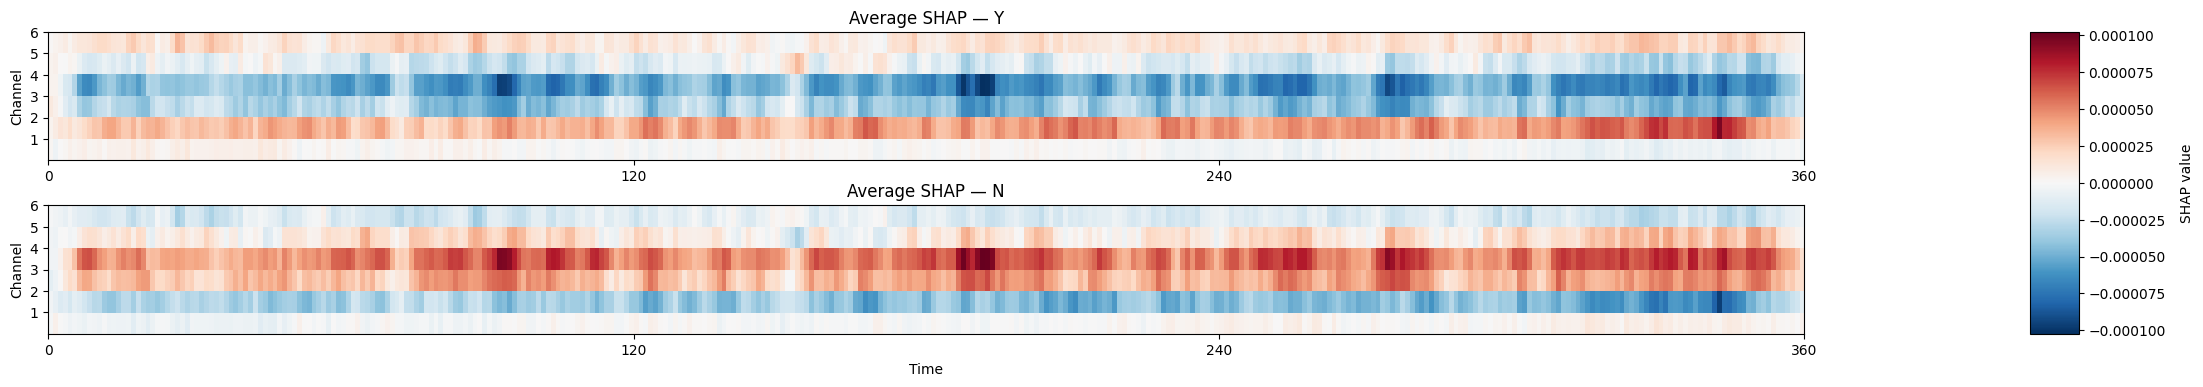

X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 3)
X_img_test.shape = (105, 360, 6, 1)
X_tab_test.shape = (105, 3)
SHAP engine: DeepExplainer (two-output)
Per-sample SHAP done:
  shapN: (105, 360, 6, 1)
  shapY: (105, 360, 6, 1)


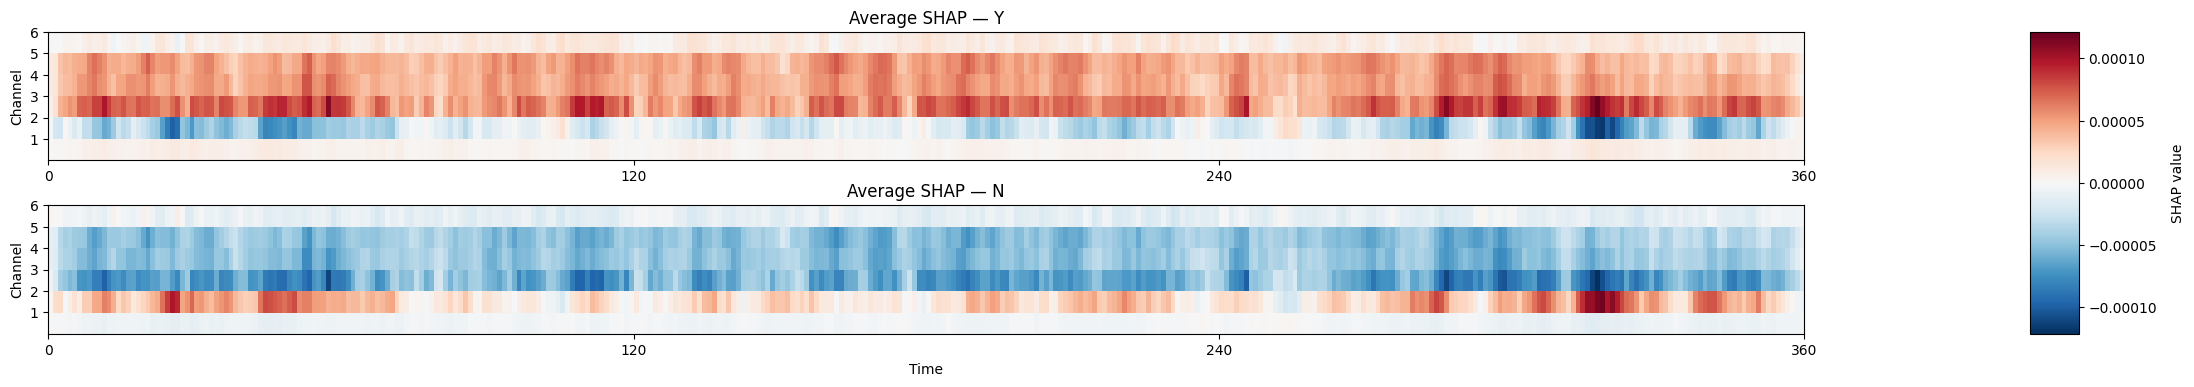

X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 3)
X_img_test.shape = (205, 360, 6, 1)
X_tab_test.shape = (205, 3)
SHAP engine: DeepExplainer (two-output)
Per-sample SHAP done:
  shapN: (205, 360, 6, 1)
  shapY: (205, 360, 6, 1)


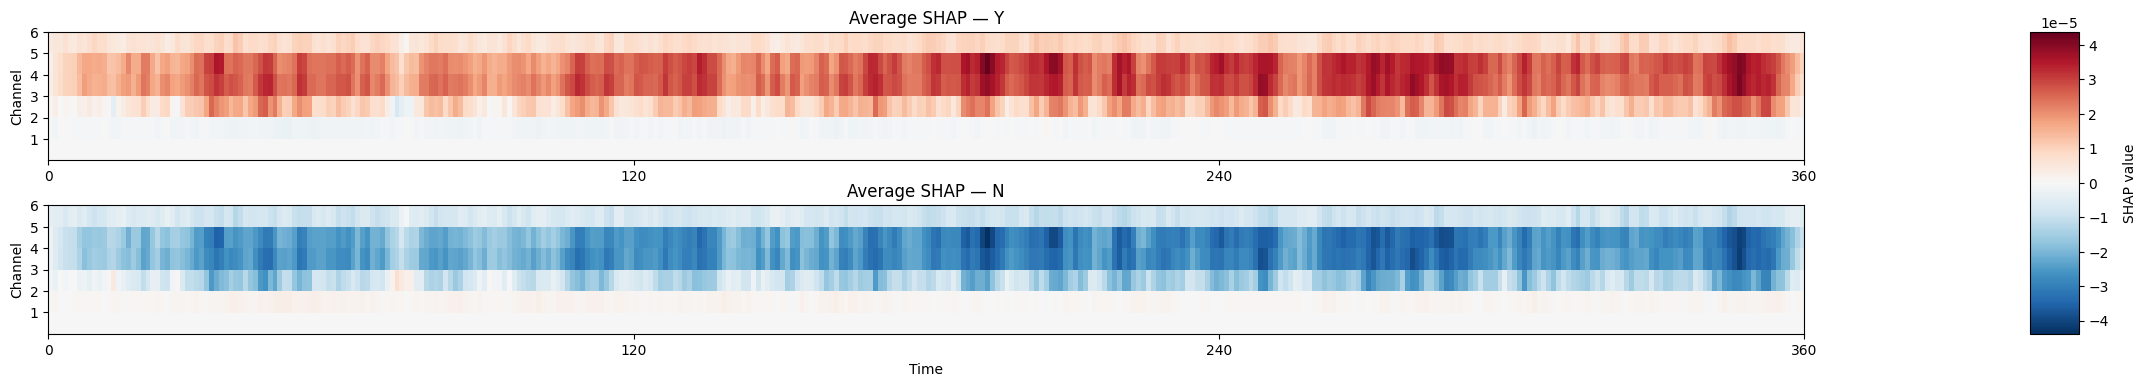

X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 3)
X_img_test.shape = (186, 360, 6, 1)
X_tab_test.shape = (186, 3)
SHAP engine: DeepExplainer (two-output)
Per-sample SHAP done:
  shapN: (186, 360, 6, 1)
  shapY: (186, 360, 6, 1)


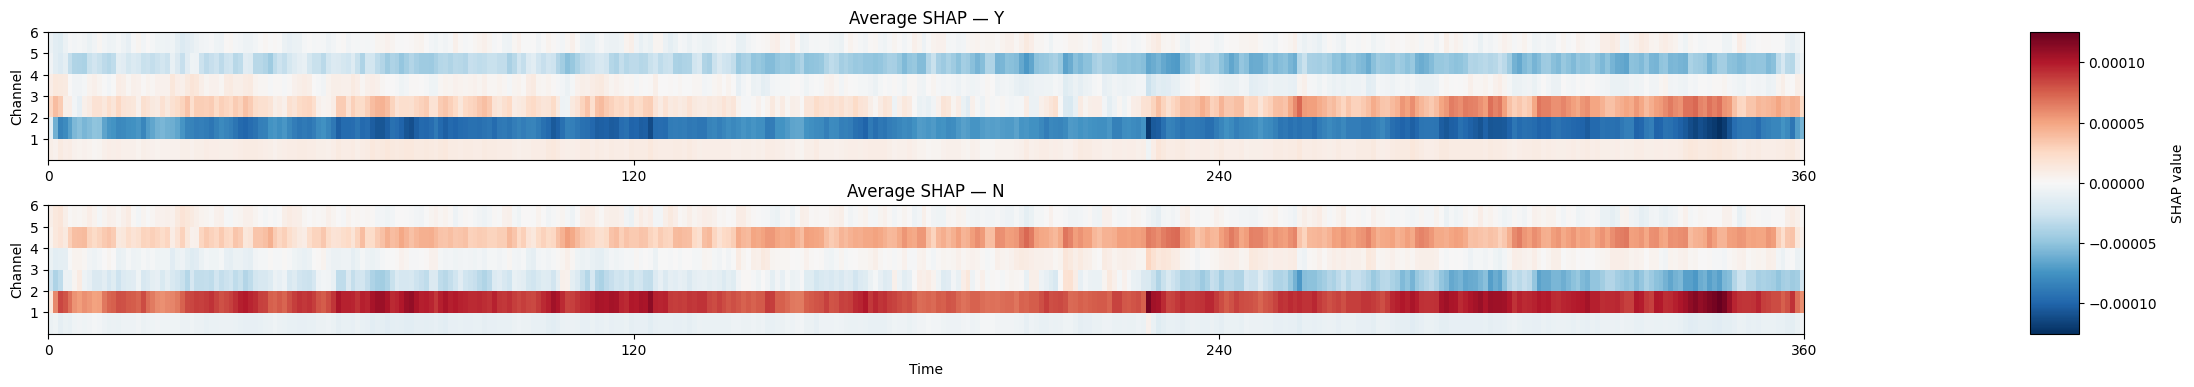

In [ ]:
results = {}
for i in range (1, 8):
   shapN, shapY, info = compute_eeg_shap_per_sample(save_dir,
                                fold_to_run= i,
                                background_n = 128)
   plot_avg_eeg_shap(shapN, shapY)
   results[i] = [compute_sum(shapY), compute_sum(shapN)]

In [ ]:
results[1]

[array([[0.0098511 ],
        [0.11573864],
        [0.16959145],
        [0.03395638],
        [0.06690436],
        [0.05717128]]),
 array([[0.0098511 ],
        [0.11573864],
        [0.16959145],
        [0.03395638],
        [0.06690436],
        [0.05717128]])]

                        Fold 1    Fold 2    Fold 3    Fold 4    Fold 5  \
Row 1 — Global 1–4hz  0.009851  0.010331  0.012405  0.013928  0.005465   
Row 2 — Left 1–4hz    0.115739  0.047162  0.027412  0.052940  0.055451   
Row 3 — Right 1–4hz   0.169591  0.055049  0.040412  0.054310  0.045040   
Row 4 — Global 4–8hz  0.033956  0.013465  0.025311  0.061082  0.027714   
Row 5 — Left 4–8hz    0.066904  0.033139  0.047190  0.045150  0.030097   
Row 6 — Right 4–8hz   0.057171  0.007472  0.029039  0.016807  0.016710   

                        Fold 6    Fold 7  
Row 1 — Global 1–4hz  0.000314  0.009838  
Row 2 — Left 1–4hz    0.002215  0.066214  
Row 3 — Right 1–4hz   0.028031  0.080079  
Row 4 — Global 4–8hz  0.018658  0.023447  
Row 5 — Left 4–8hz    0.019934  0.059195  
Row 6 — Right 4–8hz   0.007744  0.019760  


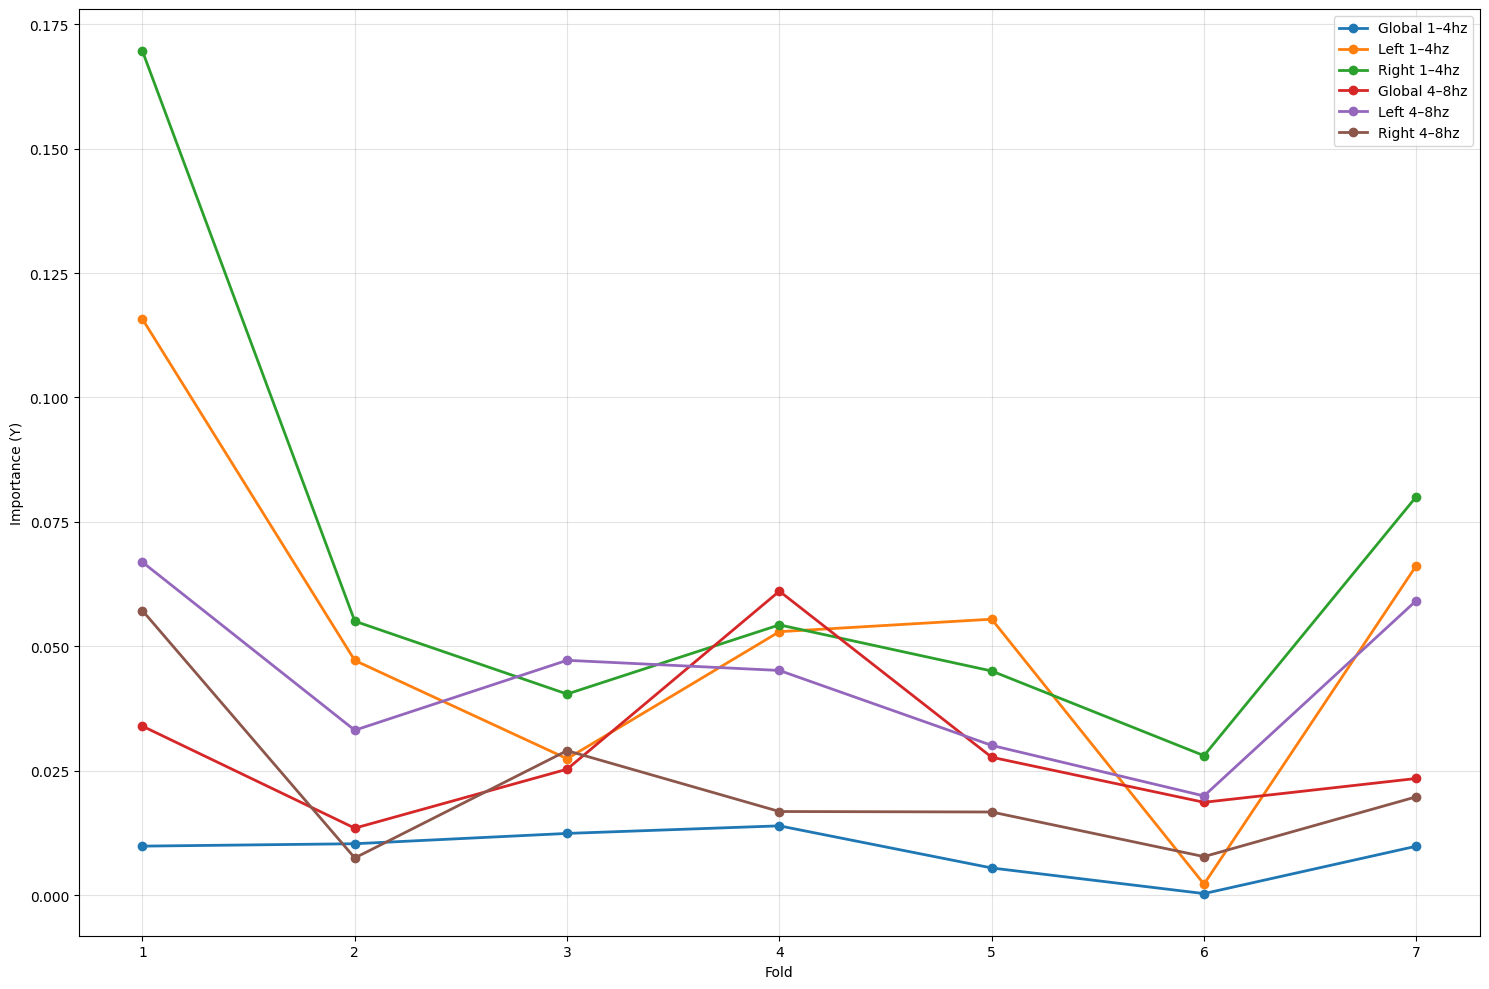

In [ ]:
# === labels for the 6 rows (row 1 is the BOTTOM band, row 6 is the TOP band) ===
# Put YOUR exact CSV non-Time column names here, in order 1..6:
ROW_LABELS = [
    "Global 1–4hz",
    "Left 1–4hz",
    "Right 1–4hz",
    "Global 4–8hz",
    "Left 4–8hz",
    "Right 4–8hz",                     # row 6 (top)
]
assert len(ROW_LABELS) == 6, "Need exactly 6 row labels."

# ---- collect Y-only importances into a (6 x F) matrix ----
folds = sorted(results.keys())
y_cols = []
for f in folds:
    y_imp = np.squeeze(np.asarray(results[f][0])).astype(float)
    if y_imp.ndim > 1:
        y_imp = y_imp.ravel()
    if y_imp.shape[0] != 6:
        raise ValueError(f"Fold {f} Y importance has shape {y_imp.shape}, expected 6.")
    y_cols.append(y_imp)

Y = np.column_stack(y_cols)  # (6, num_folds)

# Optional: table
imp_table = pd.DataFrame(Y, index=[f"Row {i+1} — {ROW_LABELS[i]}" for i in range(6)],
                         columns=[f"Fold {f}" for f in folds])
print(imp_table)

# ---- plot: 6 labeled lines over folds (Y only) ----
fig, ax = plt.subplots(figsize=(15, 10))
for r in range(6):
    ax.plot(folds, Y[r, :], marker='o', linewidth=2, label=f"{ROW_LABELS[r]}")

ax.set_xticks(folds, [str(f) for f in folds])
ax.set_xlabel("Fold")
ax.set_ylabel("Importance (Y)")
#ax.set_title("Row-wise EEG importance for Y across folds\n"
#             "(Row 1 = bottom band in the EEG image; Row 6 = top band)")
ax.grid(True, alpha=0.35)

# Put the legend outside so long labels fit
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


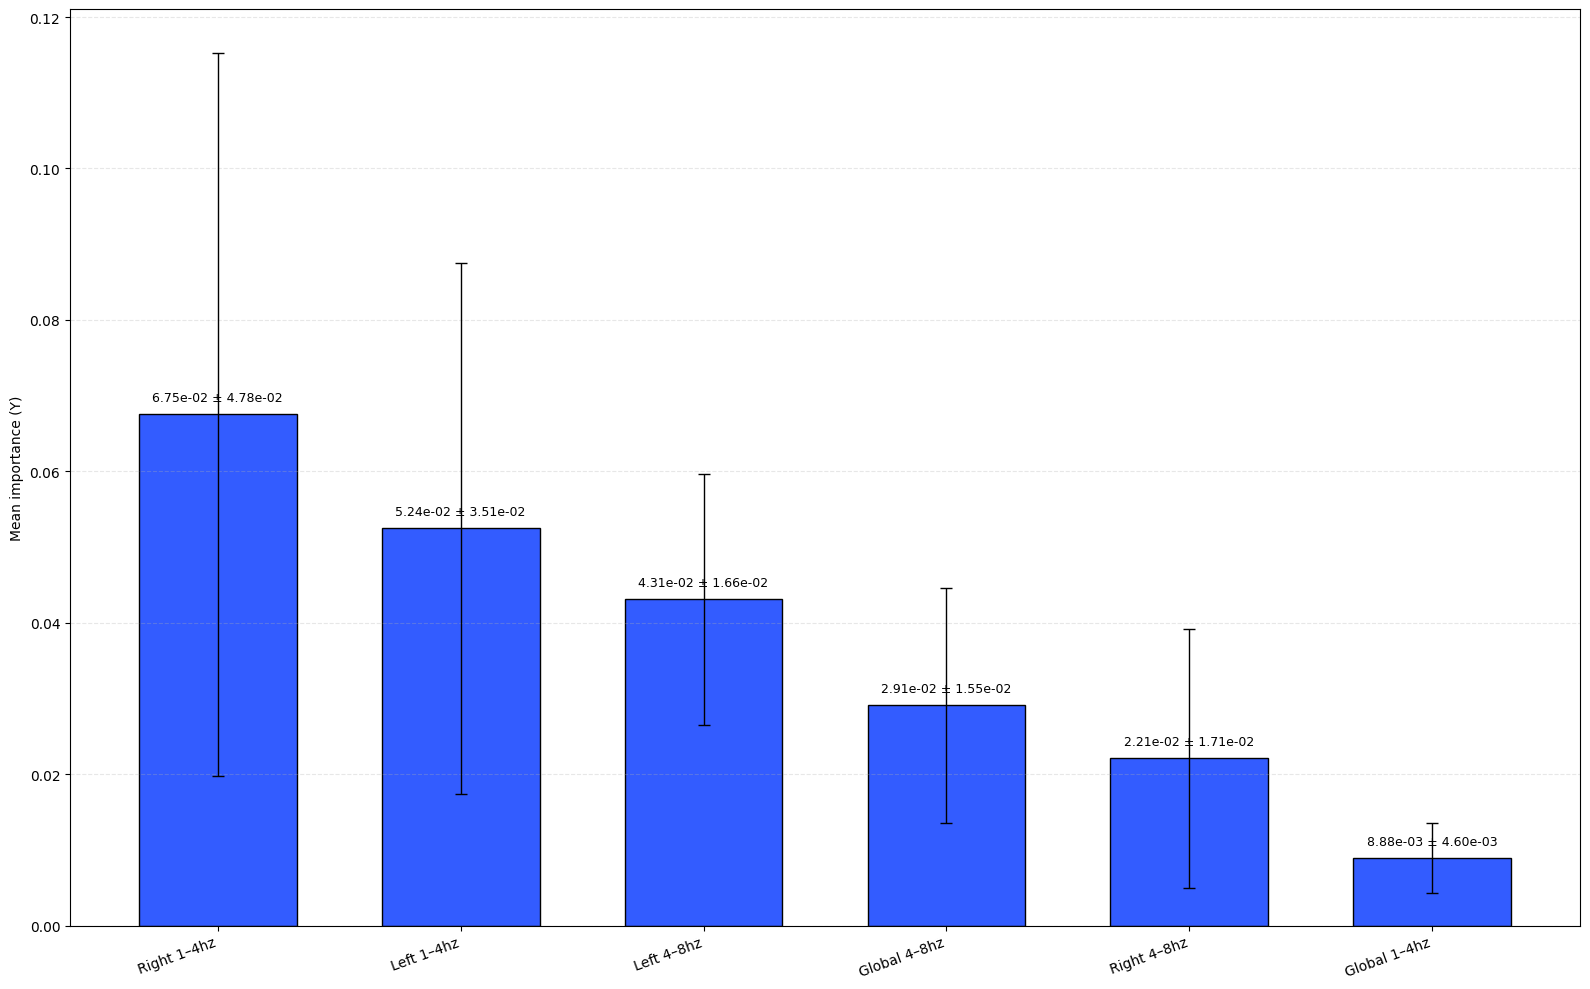

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- compute mean/std across folds (columns) ---
avg = Y.mean(axis=1)                 # shape (6,)
std = Y.std(axis=1, ddof=1)          # sample std

# --- sort by mean importance descending (optional) ---
order = np.argsort(avg)[::-1]
avg_sorted = avg[order]
std_sorted = std[order]
labels_sorted = [ROW_LABELS[i] for i in order]

# --- bar chart ---
fig, ax = plt.subplots(figsize=(16, 10))
x = np.arange(len(labels_sorted))

bars = ax.bar(
    x, avg_sorted, yerr=std_sorted, width=0.65,
    color="#335CFF", edgecolor="black", linewidth=1.0,
    error_kw=dict(ecolor="black", elinewidth=1.0, capsize=4)
)

# axes & labels
ax.set_xticks(x, labels_sorted, rotation=20, ha="right")
ax.set_ylabel("Mean importance (Y)")
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))  # scientific notation if tiny

# annotate values on top of bars
for xi, m, s in zip(x, avg_sorted, std_sorted):
    ax.text(xi, m + (0.02 * max(abs(avg_sorted)) if max(abs(avg_sorted)) > 0 else 1e-12),
            f"{m:.2e} ± {s:.2e}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


                Fold 1    Fold 2    Fold 3    Fold 4    Fold 5    Fold 6  \
Global 1–4hz  0.009851  0.010331  0.012405  0.013928  0.005465  0.000314   
Left 1–4hz    0.115739  0.047162  0.027412  0.052940  0.055451  0.002215   
Right 1–4hz   0.169591  0.055049  0.040412  0.054310  0.045040  0.028031   
Global 4–8hz  0.033956  0.013465  0.025311  0.061082  0.027714  0.018658   
Left 4–8hz    0.066904  0.033139  0.047190  0.045150  0.030097  0.019934   
Right 4–8hz   0.057171  0.007472  0.029039  0.016807  0.016710  0.007744   

                Fold 7  
Global 1–4hz  0.009838  
Left 1–4hz    0.066214  
Right 1–4hz   0.080079  
Global 4–8hz  0.023447  
Left 4–8hz    0.059195  
Right 4–8hz   0.019760  


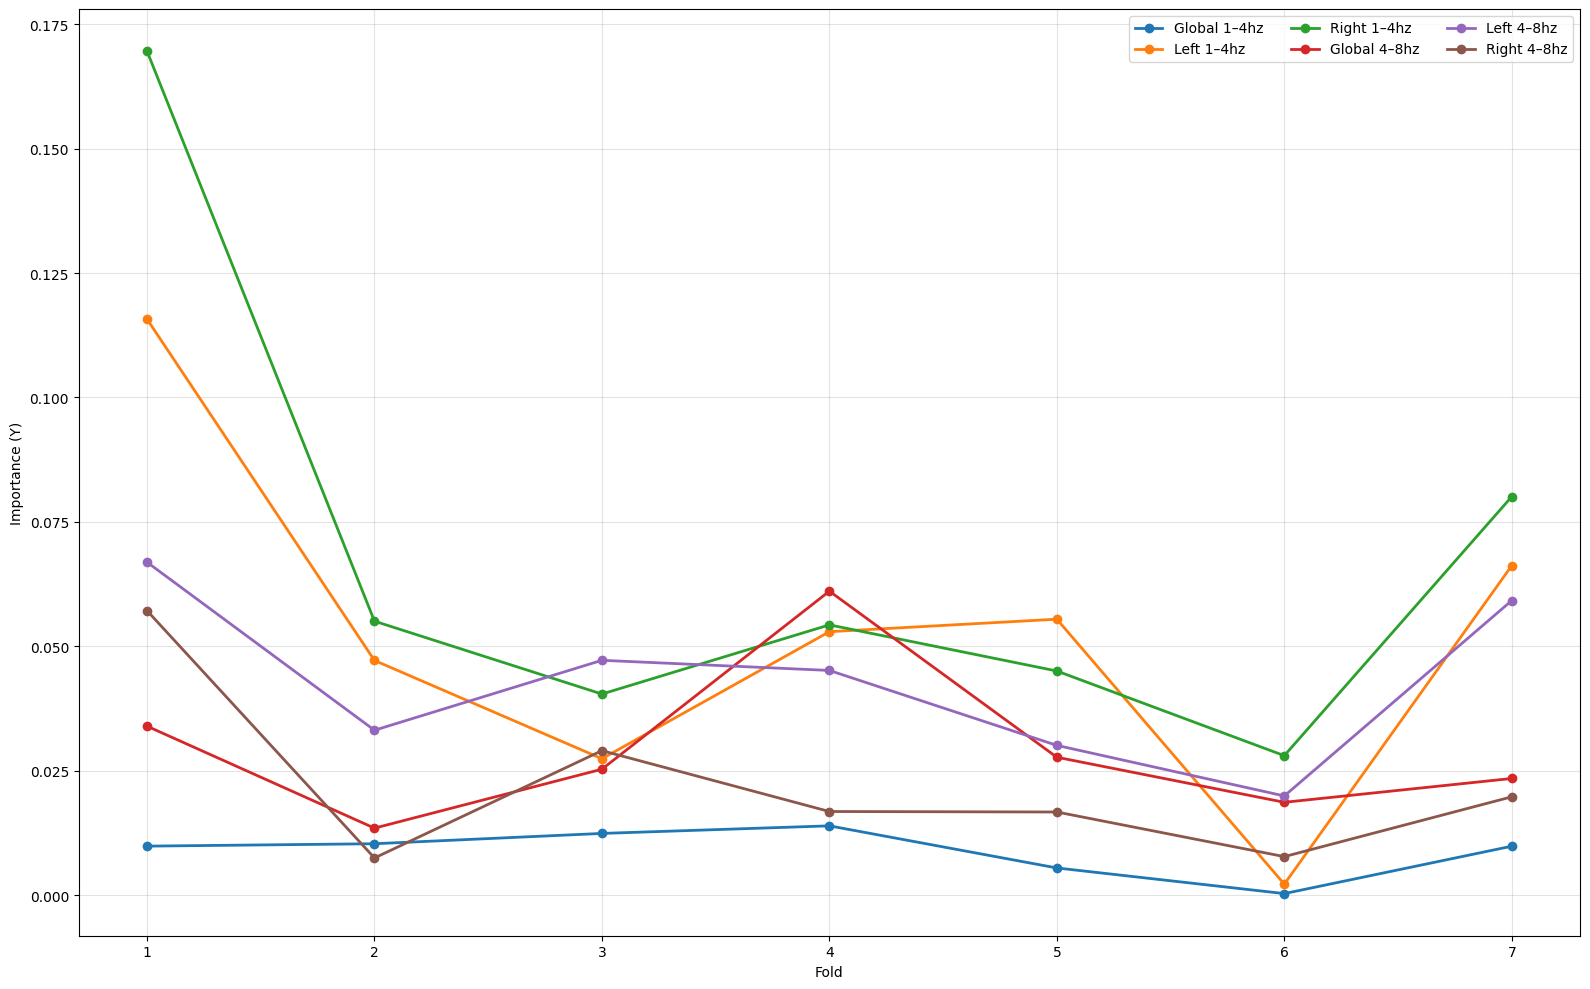

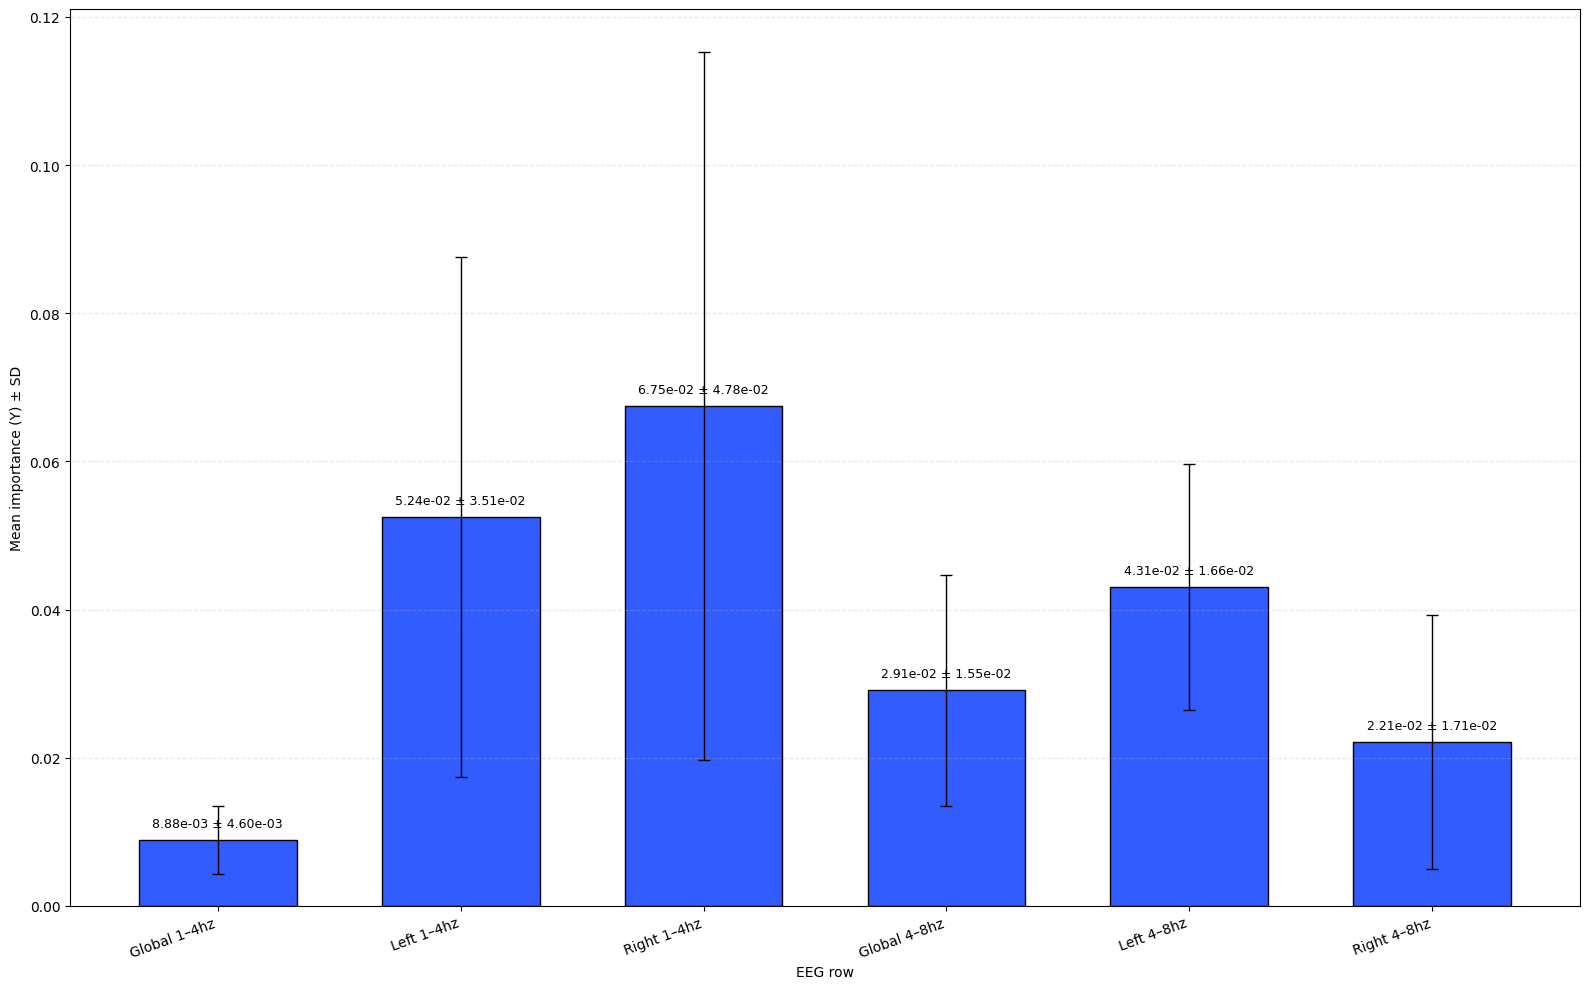

In [ ]:
# 1) Choose the exact fold order you want (no surprises)
folds = sorted(results.keys())  # or explicitly: folds = [1,2,3,4,5,6,7]

# 2) Build Y matrix strictly in that order and with your row order
y_cols = []
for f in folds:
    y_imp = np.asarray(results[f][0]).reshape(-1)  # Y only
    assert y_imp.shape[0] == len(ROW_LABELS), f"Fold {f} has {y_imp.shape[0]} rows, expected {len(ROW_LABELS)}."
    y_cols.append(y_imp)
Y = np.column_stack(y_cols)  # shape (6, len(folds))

# Optional: show the table (rows=ROW_LABELS order, columns=folds order)
imp_table = pd.DataFrame(Y, index=ROW_LABELS, columns=[f"Fold {f}" for f in folds])
print(imp_table)

# 3) Line plot across folds (row order preserved)
plt.figure(figsize=(16, 10))
for r, label in enumerate(ROW_LABELS):
    plt.plot(folds, Y[r, :], marker='o', linewidth=2, label=label)
plt.xticks(folds, [str(f) for f in folds])
plt.xlabel("Fold")
plt.ylabel("Importance (Y)")
plt.grid(True, alpha=0.35)
plt.legend(ncol=3, frameon=True)
plt.tight_layout()
plt.show()

# 4) Bar chart of mean ± SD across folds (NO sorting)
avg = Y.mean(axis=1)
std = Y.std(axis=1, ddof=1)

x = np.arange(len(ROW_LABELS))
plt.figure(figsize=(16, 10))
plt.bar(
    x, avg, yerr=std, width=0.65,
    color="#335CFF", edgecolor="black", linewidth=1.0,
    error_kw=dict(ecolor="black", elinewidth=1.0, capsize=4)
)
plt.xticks(x, ROW_LABELS, rotation=20, ha="right")
plt.ylabel("Mean importance (Y) ± SD")
plt.xlabel("EEG row")
plt.grid(axis="y", linestyle="--", alpha=0.3)

# annotate values (optional)
for xi, m, s in zip(x, avg, std):
    plt.text(xi, m + (0.02 * max(abs(avg)) if max(abs(avg)) > 0 else 1e-12),
             f"{m:.2e} ± {s:.2e}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


### All 10 features together

In [ ]:
fold_importances

[sex (1:M, 2:F)    0.059038
 age_days          0.032311
 Diagnosis         0.124328
 Name: fold_01, dtype: float64,
 sex (1:M, 2:F)    0.016668
 age_days          0.001342
 Diagnosis         0.190679
 Name: fold_02, dtype: float64,
 sex (1:M, 2:F)    0.008861
 age_days          0.002056
 Diagnosis         0.106676
 Name: fold_03, dtype: float64,
 sex (1:M, 2:F)    0.056020
 age_days          0.010823
 Diagnosis         0.175037
 Name: fold_04, dtype: float64,
 sex (1:M, 2:F)    0.040867
 age_days          0.013131
 Diagnosis         0.211145
 Name: fold_05, dtype: float64,
 sex (1:M, 2:F)    0.022032
 age_days          0.003172
 Diagnosis         0.268430
 Name: fold_06, dtype: float64,
 sex (1:M, 2:F)    0.058910
 age_days          0.017131
 Diagnosis         0.211180
 Name: fold_07, dtype: float64]


=== Per-fold combined table (EEG + tabular) ===
                   fold_01  fold_02  fold_03  fold_04  fold_05  fold_06  fold_07     mean      std
EEG: Global 1–4hz 0.009851 0.010331 0.012405 0.013928 0.005465 0.000314 0.009838 0.008876 0.004599
EEG: Left 1–4hz   0.115739 0.047162 0.027412 0.052940 0.055451 0.002215 0.066214 0.052448 0.035077
EEG: Right 1–4hz  0.169591 0.055049 0.040412 0.054310 0.045040 0.028031 0.080079 0.067502 0.047794
EEG: Global 4–8hz 0.033956 0.013465 0.025311 0.061082 0.027714 0.018658 0.023447 0.029090 0.015536
EEG: Left 4–8hz   0.066904 0.033139 0.047190 0.045150 0.030097 0.019934 0.059195 0.043087 0.016591
EEG: Right 4–8hz  0.057171 0.007472 0.029039 0.016807 0.016710 0.007744 0.019760 0.022101 0.017131
sex (1:M, 2:F)    0.059038 0.016668 0.008861 0.056020 0.040867 0.022032 0.058910 0.037485 0.021486
age_days          0.032311 0.001342 0.002056 0.010823 0.013131 0.003172 0.017131 0.011424 0.011027
Diagnosis         0.124328 0.190679 0.106676 0.175037 0.2111

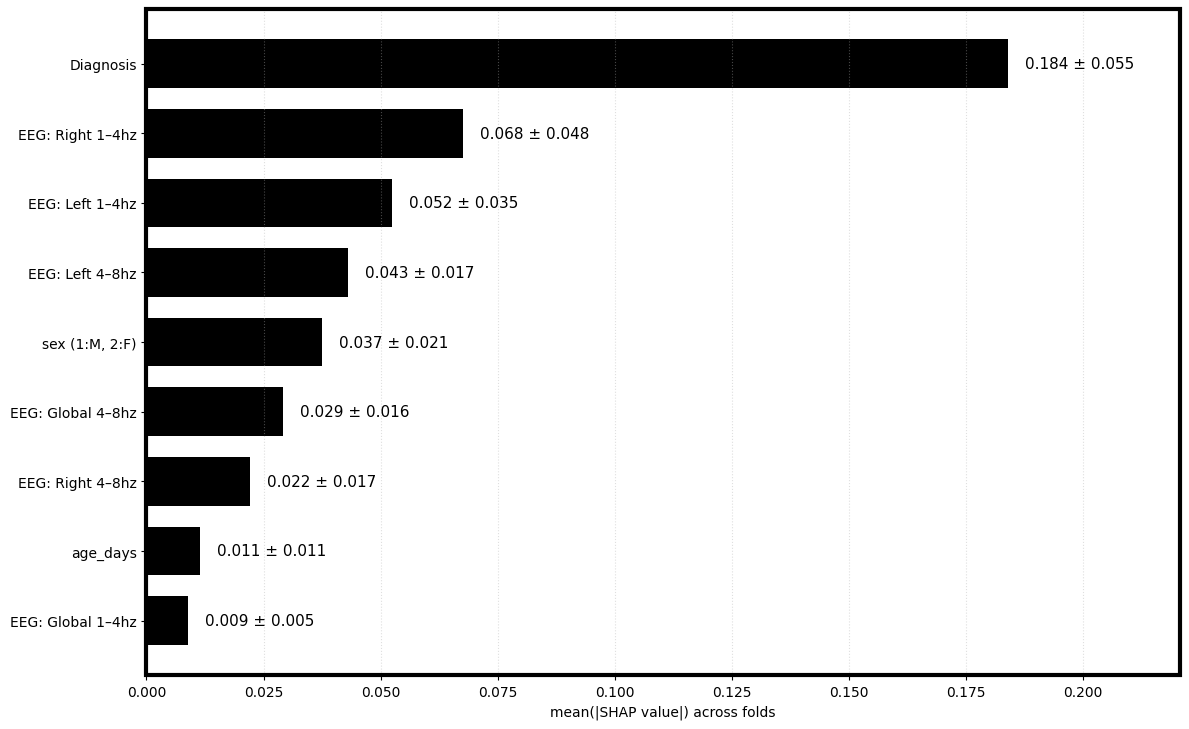

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ---------- 1) Build per-fold tables ----------

# A) Tabular: fold_importances is a list[Series], each named "fold_XX"
tab_table = pd.concat(fold_importances, axis=1)             # rows=tab features, cols=fold_XX
# ensure fold columns sorted by number
tab_cols_sorted = sorted(tab_table.columns)                 # e.g., ["fold_01", ...]
tab_table = tab_table.reindex(columns=tab_cols_sorted)

# B) EEG (6 rows): Y shape should be (6, num_folds) in the same 'folds' order you chose
# turn it into a DataFrame with matching "fold_XX" column names
eeg_cols = [f"fold_{f:02d}" for f in folds]
if Y.shape[1] != len(eeg_cols):
    raise ValueError(f"EEG Y has {Y.shape[1]} columns but {len(eeg_cols)} folds were specified.")
eeg_table = pd.DataFrame(Y, index=ROW_LABELS, columns=eeg_cols)

# Prefix row names so it’s clear in the combined view
eeg_table.index = [f"EEG: {r}" for r in eeg_table.index]

# Align both tables to the same column order (intersection, to be safe)
common_cols = [c for c in tab_cols_sorted if c in eeg_table.columns]
if not common_cols:
    raise RuntimeError("No common fold columns between EEG and tabular tables.")
tab_table  = tab_table.reindex(columns=common_cols)
eeg_table  = eeg_table.reindex(columns=common_cols)

# ---------- 2) Combine (10 rows total = 6 EEG + 4 tabular) ----------
combined = pd.concat([eeg_table, tab_table], axis=0)        # rows = 10 features, cols = folds
# compute mean & std across folds
combined["mean"] = combined[common_cols].mean(axis=1, skipna=True)
combined["std"]  = combined[common_cols].std(axis=1, ddof=1, skipna=True)

# Nice summary (descending by mean)
summary = (
    combined[["mean", "std"]]
    .sort_values("mean", ascending=False)
    .rename_axis("feature")
    .reset_index()
    .rename(columns={"mean":"mean_importance", "std":"std_importance"})
)

# Print tables
with pd.option_context('display.float_format', '{:.6f}'.format):
    print("\n=== Per-fold combined table (EEG + tabular) ===")
    print(combined[common_cols + ["mean","std"]].to_string())
    print("\n=== Mean ± SD across folds (sorted) ===")
    print(summary.to_string(index=False))

# ---------- 3) Plot: top 10 horizontal bars with mean ± SD ----------
TOP_N = min(10, len(summary))  # will be 10 exactly if you have 6+4 features
names = summary["feature"].values[:TOP_N]
means = summary["mean_importance"].values[:TOP_N]
stds  = summary["std_importance"].values[:TOP_N]

fig, ax = plt.subplots(figsize=(12, max(6, 0.6*TOP_N + 2)))
ypos = np.arange(len(names))
ax.barh(ypos, means, height=0.7, color="black")
ax.invert_yaxis()

ax.set_yticks(ypos)
ax.set_yticklabels(names)
ax.set_xlabel("mean(|SHAP value|) across folds")
ax.grid(axis="x", linestyle=":", alpha=0.4)

xmax = float(means.max()) if len(means) else 1.0
ax.set_xlim(0, xmax * 1.20 if xmax > 0 else 1.0)

# annotate "mean ± SD"
offset = xmax * 0.02 if xmax > 0 else 0.02
for y, m, s in zip(ypos, means, stds):
    ax.text(m + offset, y, f"{m:.3f} ± {s:.3f}", va="center", ha="left", fontsize=11, color="black")

# clean spines + bold outer frame
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
frame = Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor="black", linewidth=3.0, clip_on=False, zorder=10)
ax.add_patch(frame)

plt.tight_layout()
plt.show()

# ---------- 4) (Optional) Save CSVs ----------
#combined.to_csv(Path(save_dir) / "combined_eeg_tab_importances_by_fold.csv")
summary.to_csv(Path(save_dir) / "combined_eeg_tab_summary_mean_sd.csv", index=False)


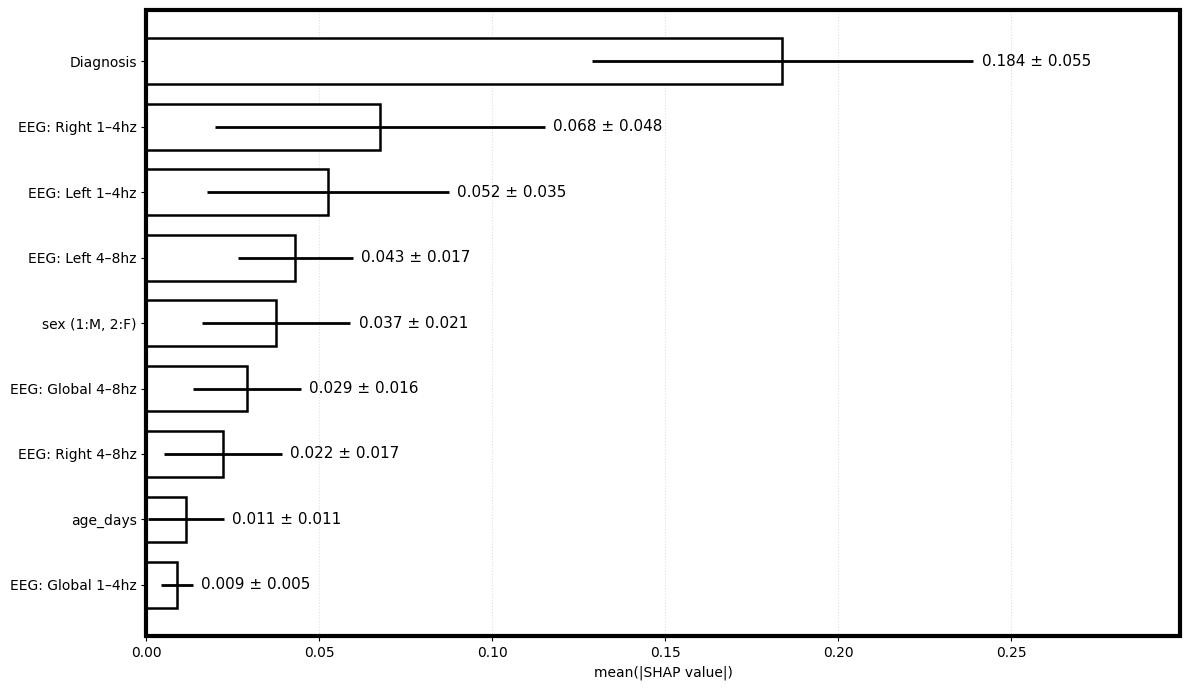

In [ ]:
# ---------- Horizontal bars: white bars + black std sticks + non-overlapping labels ----------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.patches import Rectangle

def _build_feature_stats_from_anything():
    """
    Returns (feature_names, feature_means, feature_stds) as numpy arrays.
    Priority:
      1) Predefined arrays: feature_names, feature_means, feature_stds
      2) 'summary' DataFrame with columns: ['feature','mean_importance','std_importance']
      3) 'combined' DataFrame: fold columns + 'mean','std'
      4) Rebuild from fold_importances (list of Series) + EEG Y/ROW_LABELS/folds
    """
    g = globals()

    # 1) If arrays already exist, use them
    if all(k in g for k in ["feature_names", "feature_means", "feature_stds"]):
        fn = np.asarray(g["feature_names"])
        fm = np.asarray(g["feature_means"], dtype=float)
        fs = np.asarray(g["feature_stds"], dtype=float)
        return fn, fm, fs

    # 2) Use 'summary' DataFrame
    if "summary" in g and isinstance(g["summary"], pd.DataFrame):
        summary = g["summary"]
        if {"feature", "mean_importance", "std_importance"} <= set(summary.columns):
            fn = summary["feature"].to_numpy()
            fm = summary["mean_importance"].to_numpy(dtype=float)
            fs = summary["std_importance"].to_numpy(dtype=float)
            return fn, fm, fs

    # 3) Use 'combined' DataFrame (compute mean/std from fold columns if needed)
    if "combined" in g and isinstance(g["combined"], pd.DataFrame):
        combined = g["combined"].copy()
        cols = [c for c in combined.columns if c.startswith("fold_")]
        if not cols:
            # fallback to any numeric columns (except mean/std if present)
            cols = [c for c in combined.columns if pd.api.types.is_numeric_dtype(combined[c])]
            cols = [c for c in cols if c not in ("mean","std")]
        if not cols:
            raise RuntimeError("Found 'combined' but no fold columns to aggregate.")
        # compute mean/std if absent
        if "mean" not in combined.columns:
            combined["mean"] = combined[cols].mean(axis=1, skipna=True)
        if "std" not in combined.columns:
            combined["std"]  = combined[cols].std(axis=1, ddof=1, skipna=True)
        fn = combined.index.to_numpy()
        fm = combined["mean"].to_numpy(dtype=float)
        fs = combined["std"].to_numpy(dtype=float)
        return fn, fm, fs

    # 4) Rebuild from fold_importances + EEG Y/ROW_LABELS/folds
    if not all(k in g for k in ["fold_importances", "Y", "ROW_LABELS", "folds"]):
        raise RuntimeError(
            "No feature stats found. Provide feature_names/means/stds, "
            "or 'summary', or 'combined', or (fold_importances + Y + ROW_LABELS + folds)."
        )

    fold_importances = g["fold_importances"]  # list of Series, name="fold_XX"
    Y = np.asarray(g["Y"])
    ROW_LABELS = list(g["ROW_LABELS"])
    folds = list(g["folds"])

    # Tabular table
    tab_table = pd.concat(fold_importances, axis=1)  # rows=tab features, cols=fold_XX
    tab_cols_sorted = sorted(tab_table.columns)
    tab_table = tab_table.reindex(columns=tab_cols_sorted)

    # EEG table
    eeg_cols = [f"fold_{f:02d}" for f in folds]
    eeg_table = pd.DataFrame(Y, index=[f"EEG: {r}" for r in ROW_LABELS], columns=eeg_cols)

    # Align to common columns
    common_cols = [c for c in tab_cols_sorted if c in eeg_table.columns]
    if not common_cols:
        raise RuntimeError("No common folds between EEG and tabular tables.")
    tab_table = tab_table.reindex(columns=common_cols)
    eeg_table = eeg_table.reindex(columns=common_cols)

    combined_local = pd.concat([eeg_table, tab_table], axis=0)
    means = combined_local[common_cols].mean(axis=1, skipna=True)
    stds  = combined_local[common_cols].std(axis=1, ddof=1, skipna=True)

    fn = means.index.to_numpy()
    fm = means.to_numpy(dtype=float)
    fs = stds.to_numpy(dtype=float)
    return fn, fm, fs

# ---- build the stats (wherever they can be sourced from) ----
feature_names, feature_means, feature_stds = _build_feature_stats_from_anything()

# ---- plotting (your original look, but safe) ----
# sort by mean descending
order  = np.argsort(feature_means)[::-1]
names  = [feature_names[i] for i in order]
means  = feature_means[order]
stds   = feature_stds[order]

fig, ax = plt.subplots(figsize=(12, 7))

ypos = np.arange(len(names))

# white bars with black edges
ax.barh(ypos, means, height=0.7,
        facecolor="white", edgecolor="black", linewidth=1.8, zorder=2)

# black "sticks" for ± std
ax.errorbar(means, ypos, xerr=stds,
            fmt="none", ecolor="black", elinewidth=2.0, capsize=0, zorder=3)

# largest on top
ax.invert_yaxis()
ax.set_yticks(ypos); ax.set_yticklabels(names)
ax.set_xlabel("mean(|SHAP value|)")
ax.grid(axis="x", linestyle=":", alpha=0.4, zorder=1)

# give room for the errorbars + text
xmax = float(np.max(means + stds)) if len(means) else 1.0
ax.set_xlim(0, xmax * 1.25)

# annotate to the right of the whisker
text_transform = mtransforms.ScaledTranslation(6/72., 0, fig.dpi_scale_trans)  # 6 pt right
for y, m, s in zip(ypos, means, stds):
    x_at_label = m + s  # end of whisker
    ax.text(x_at_label, y, f"{m:.3f} ± {s:.3f}",
            transform=ax.transData + text_transform,
            va="center", ha="left", fontsize=11, color="black", zorder=4)

# hide default spines
for s in ax.spines.values():
    s.set_visible(False)

# add black frame
frame = Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                  fill=False, edgecolor="black", linewidth=3.0,
                  clip_on=False, zorder=10)
ax.add_patch(frame)

plt.tight_layout()
plt.show()


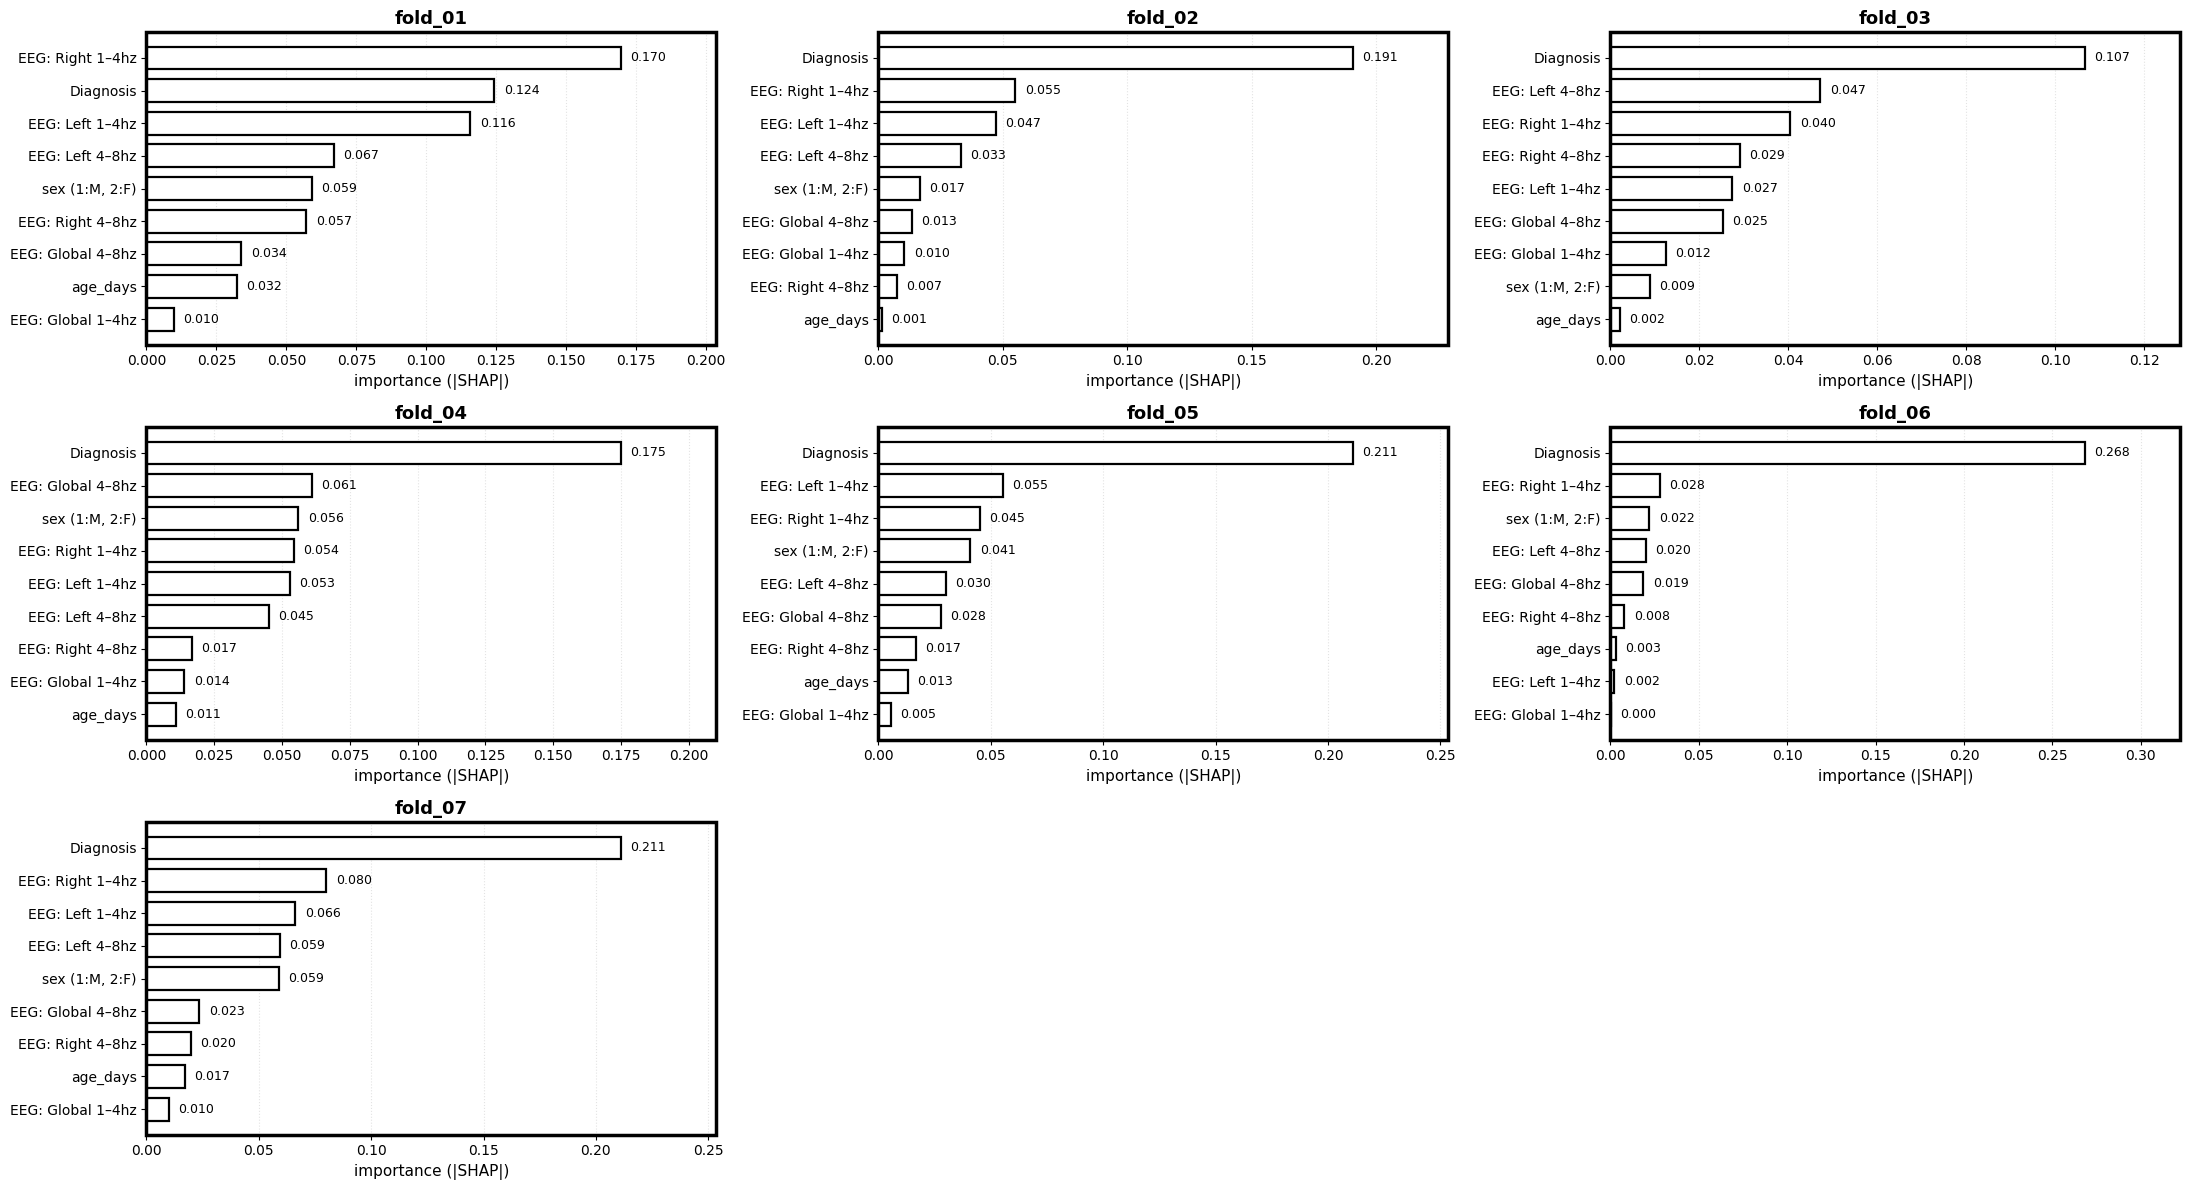

In [ ]:
# ===== Per-fold importance plots (EEG 6 + tabular), no averaging =====
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Rectangle

# ---- inputs expected in your session ----
# fold_importances : list[pd.Series], each named "fold_XX" with tabular importances
# Y                : np.ndarray shape (6, F) with EEG importances across folds (your results[...] Y)
# ROW_LABELS       : list[str] of length 6 for EEG rows (or we’ll provide defaults)
# folds            : list[int] fold numbers in order that align with Y’s columns (optional—will infer)

# --- sanity/defaults ---
try:
    ROW_LABELS
except NameError:
    ROW_LABELS = [
        "Global 1–4 Hz","Left 1–4 Hz","Right 1–4 Hz",
        "Global 4–8 Hz","Left 4–8 Hz","Right 4–8 Hz",
    ]

# Build a tabular importance table: rows=tab features, cols=fold_XX
tab_table = pd.concat(fold_importances, axis=1)  # columns like 'fold_01', ...
tab_table = tab_table.sort_index(axis=1)         # ensure fold_01, fold_02, ...

# Figure out folds and alignment with Y
fold_cols = list(tab_table.columns)                     # ['fold_01', ...]
fold_nums = [int(c.split("_")[1]) for c in fold_cols]   # [1,2,...]
# If a 'folds' list exists, intersect in that order; otherwise use tab_table order
try:
    folds
    folds_common = [f for f in folds if f in fold_nums]
    if not folds_common:
        folds_common = fold_nums
except NameError:
    folds_common = fold_nums

# Check Y has same #folds as folds_common
Y = np.asarray(Y)
if Y.ndim != 2 or Y.shape[0] != 6:
    raise ValueError(f"Y must be (6, F). Got {Y.shape}.")

if Y.shape[1] != len(folds_common):
    # Try to realign using tab_table columns strictly
    # Rebuild Y_view taking columns in the order of fold_cols/fold_nums
    # Assume your current Y columns match folds in ascending order; we’ll just warn if mismatch.
    print(f"(Note) Y has {Y.shape[1]} columns, folds_common has {len(folds_common)}. "
          f"Proceeding with min of the two after truncation.")
    F = min(Y.shape[1], len(folds_common))
    Y = Y[:, :F]
    folds_common = folds_common[:F]
    fold_cols = [f"fold_{f:02d}" for f in folds_common]
else:
    fold_cols = [f"fold_{f:02d}" for f in folds_common]

# ==== Build combined per-fold Series ====
# For each fold f:
#   - EEG features: take Y[:, idx]
#   - Tabular features: tab_table[fold_XX]
def _combined_series_for_fold(idx, fnum, fold_col):
    # EEG vector for this fold
    eeg_vals = Y[:, idx]
    eeg_index = [f"EEG: {lab}" for lab in ROW_LABELS]
    eeg_s = pd.Series(eeg_vals, index=eeg_index, dtype=float)

    # Tabular vector for this fold
    tab_s = tab_table[fold_col]  # Series indexed by feature names
    tab_s = tab_s.astype(float)

    # Combine
    comb = pd.concat([eeg_s, tab_s], axis=0)
    return comb

combined_by_fold = {}
for idx, f in enumerate(folds_common):
    col = f"fold_{f:02d}"
    combined_by_fold[col] = _combined_series_for_fold(idx, f, col)

# Optional: export per-fold combined tables
# for col, ser in combined_by_fold.items():
#     ser.sort_values(ascending=False).to_csv(f"combined_importances_{col}.csv")

# ==== Plot grid of per-fold horizontal bar charts ====
def plot_per_fold_importances(combined_by_fold, top_k=None, figsize=(18, 12)):
    """
    Draw one subplot per fold. Bars sorted within fold (desc).
    top_k: limit number of rows per fold (e.g., 12); None = all.
    """
    fold_names = list(combined_by_fold.keys())
    F = len(fold_names)
    if F == 0:
        print("No folds to plot.")
        return

    # Choose a tidy grid (<=3 columns)
    ncols = 3 if F > 6 else (2 if F > 3 else 1)
    nrows = math.ceil(F / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, squeeze=False)
    axlist = axes.ravel()

    for ax, col in zip(axlist, fold_names):
        ser = combined_by_fold[col].copy()
        # sort desc
        ser = ser.sort_values(ascending=False)
        if top_k is not None:
            ser = ser.iloc[:top_k]

        names = ser.index.to_list()
        vals  = ser.values.astype(float)

        ypos = np.arange(len(names))
        # white bars with black edges
        ax.barh(ypos, vals, height=0.7, facecolor="white", edgecolor="black", linewidth=1.6, zorder=2)
        ax.invert_yaxis()
        ax.set_yticks(ypos)
        ax.set_yticklabels(names, fontsize=10)
        ax.set_xlabel("importance (|SHAP|)", fontsize=11)
        ax.set_title(col, fontsize=13, fontweight="bold")
        ax.grid(axis="x", linestyle=":", alpha=0.35, zorder=1)

        # room for labels
        xmax = float(np.max(vals)) if len(vals) else 1.0
        ax.set_xlim(0, xmax * 1.20)

        # annotate numeric values at bar ends
        off = xmax * 0.02 if xmax > 0 else 1e-3
        for y, v in zip(ypos, vals):
            ax.text(v + off, y, f"{v:.3f}", va="center", ha="left", fontsize=9, color="black")

        # clean spines + add frame
        for s in ax.spines.values():
            s.set_visible(False)
        frame = Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                          fill=False, edgecolor="black", linewidth=2.5,
                          clip_on=False, zorder=10)
        ax.add_patch(frame)

    # Hide any unused subplots
    for ax in axlist[F:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# ==== Call the plotter ====
# top_k=None plots all features; set e.g., top_k=12 if you want to cap the list per fold.
plot_per_fold_importances(combined_by_fold, top_k=None, figsize=(22, 12))


### The swam plot for EEG

X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 3)
X_img_test.shape = (275, 360, 6, 1)
X_tab_test.shape = (275, 3)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


SHAP engine: DeepExplainer (two-output)


Per-sample SHAP done:
  shapN: (275, 360, 6, 1)
  shapY: (275, 360, 6, 1)
X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 3)
X_img_test.shape = (152, 360, 6, 1)
X_tab_test.shape = (152, 3)
SHAP engine: DeepExplainer (two-output)


Per-sample SHAP done:
  shapN: (152, 360, 6, 1)
  shapY: (152, 360, 6, 1)
X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 3)
X_img_test.shape = (191, 360, 6, 1)
X_tab_test.shape = (191, 3)
SHAP engine: DeepExplainer (two-output)


Per-sample SHAP done:
  shapN: (191, 360, 6, 1)
  shapY: (191, 360, 6, 1)
X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 3)
X_img_test.shape = (106, 360, 6, 1)
X_tab_test.shape = (106, 3)
SHAP engine: DeepExplainer (two-output)


Per-sample SHAP done:
  shapN: (106, 360, 6, 1)
  shapY: (106, 360, 6, 1)
X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 3)
X_img_test.shape = (105, 360, 6, 1)
X_tab_test.shape = (105, 3)
SHAP engine: DeepExplainer (two-output)


Per-sample SHAP done:
  shapN: (105, 360, 6, 1)
  shapY: (105, 360, 6, 1)
X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 3)
X_img_test.shape = (205, 360, 6, 1)
X_tab_test.shape = (205, 3)
SHAP engine: DeepExplainer (two-output)


Per-sample SHAP done:
  shapN: (205, 360, 6, 1)
  shapY: (205, 360, 6, 1)
X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 3)
X_img_test.shape = (186, 360, 6, 1)
X_tab_test.shape = (186, 3)
SHAP engine: DeepExplainer (two-output)
Per-sample SHAP done:
  shapN: (186, 360, 6, 1)
  shapY: (186, 360, 6, 1)


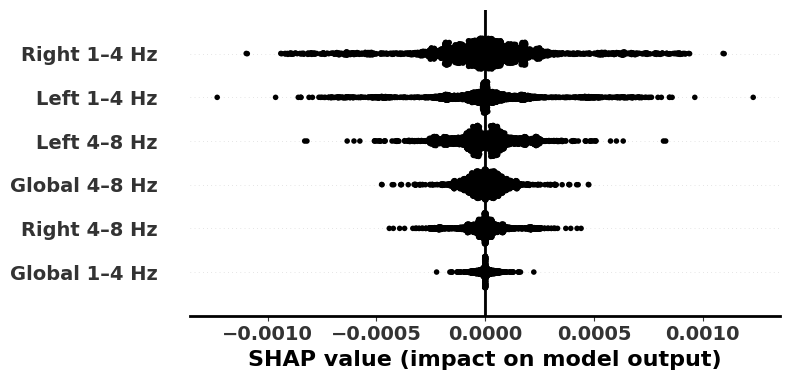

In [ ]:
# === EEG beeswarm from your per-fold SHAP (shapY, shapN) ===
# Expects you already ran:
# results = {}
# for i in range(1, 8):
#     shapN, shapY, info = compute_eeg_shap_per_sample(...)
#     plot_avg_eeg_shap(shapN, shapY)
#     results[i] = [compute_sum(shapY), compute_sum(shapN)]
#
# NOTE: to make the beeswarm, we need the *per-sample* SHAP arrays.
# If you still have shapY/shapN available in memory per fold, reuse them.
# If not, just re-call compute_eeg_shap_per_sample inside the loop below.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import shap

# 1) Helper to reduce SHAP to (N, 6) while keeping SIGN
def _reduce_eeg_shap_signed(A):
    A = np.asarray(A)
    if A.ndim == 4:
        # (N, T, C, 1) -> mean over time, squeeze last dim -> (N, C)
        A = A.mean(axis=1)
        if A.shape[-1] == 1:
            A = A[..., 0]
    elif A.ndim == 3:
        # (N, T, C) -> mean over time
        A = A.mean(axis=1)
    elif A.ndim == 2:
        # already (N, C)
        pass
    else:
        raise ValueError(f"Unexpected SHAP shape {A.shape}; expected (N,6) or (N,T,6[,1]).")
    if A.shape[1] != 6:
        raise ValueError(f"Expect 6 EEG features (columns); got {A.shape[1]}.")
    return A.astype(float)

# 2) Collect per-fold per-sample EEG SHAP (both classes) → stack across folds
S_parts = []
for fold in range(1, 8):
    # recompute per fold to ensure we have the per-sample arrays
    shapN, shapY, info = compute_eeg_shap_per_sample(save_dir, fold_to_run=fold, background_n=128)
    Y2 = _reduce_eeg_shap_signed(shapY)   # (NY, 6)
    N2 = _reduce_eeg_shap_signed(shapN)   # (NN, 6)
    S_parts.append(np.vstack([Y2, N2]))   # concat per-class samples for this fold

# All folds combined: (M_total, 6)
S_eeg = np.vstack(S_parts) if len(S_parts) else np.zeros((0, 6), dtype=float)

# 3) Make a SHAP Explanation (we don’t use feature values for color → zeros)
EEG_LABELS = [
    "Global 1–4 Hz", "Left 1–4 Hz", "Right 1–4 Hz",
    "Global 4–8 Hz", "Left 4–8 Hz", "Right 4–8 Hz",
]
exp_eeg = shap.Explanation(
    values=S_eeg,                       # (M, 6) signed SHAP
    data=np.zeros_like(S_eeg),          # dummy data so all dots are the same color
    feature_names=EEG_LABELS
)

# 4) Beeswarm: black dots, bold labels, bold frame
W, H = 14, 9
blackmap = LinearSegmentedColormap.from_list("blackmap", ["#000000", "#000000"])

plt.figure(figsize=(W, H))
# newer SHAP supports dot_size; if not, the fallback call works
try:
    shap.plots.beeswarm(
        exp_eeg, max_display=6, color=blackmap,
        color_bar=False, show=False, plot_size=(W, H), dot_size=14
    )
except TypeError:
    shap.plots.beeswarm(
        exp_eeg, max_display=6, color=blackmap,
        color_bar=False, show=False
    )

ax = plt.gca()
ax.set_xlabel("SHAP value (impact on model output)", fontsize=16, fontweight="bold")

for lbl in ax.get_xticklabels():
    lbl.set_fontsize(14); lbl.set_fontweight("bold")
for lbl in ax.get_yticklabels():
    lbl.set_fontsize(14); lbl.set_fontweight("bold")

for side in ["bottom", "left", "top", "right"]:
    ax.spines[side].set_linewidth(2.0)
    ax.spines[side].set_color("black")

ax.axvline(0, color="black", linewidth=2.0)

plt.tight_layout()
plt.show()


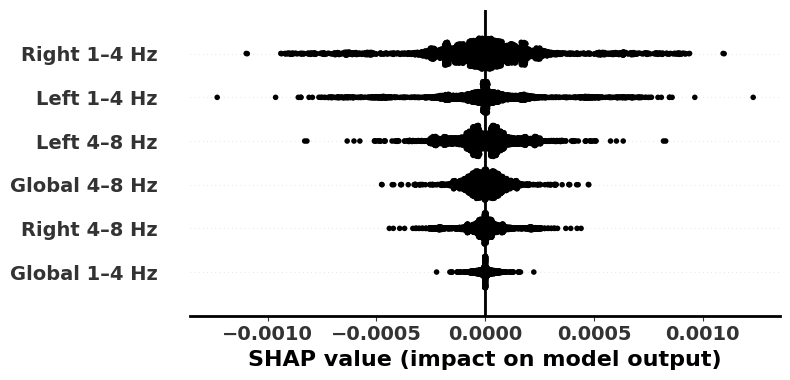

In [ ]:
# 4) Beeswarm: black dots, bold labels, bold frame
W, H = 14, 9
blackmap = LinearSegmentedColormap.from_list("blackmap", ["#000000", "#000000"])

plt.figure(figsize=(W, H))
# newer SHAP supports dot_size; if not, the fallback call works
try:
    shap.plots.beeswarm(
        exp_eeg, max_display=6, color=blackmap,
        color_bar=False, show=False, plot_size=(W, H), dot_size=14
    )
except TypeError:
    shap.plots.beeswarm(
        exp_eeg, max_display=6, color=blackmap,
        color_bar=False, show=False
    )

ax = plt.gca()
ax.set_xlabel("SHAP value (impact on model output)", fontsize=16, fontweight="bold")

for lbl in ax.get_xticklabels():
    lbl.set_fontsize(14); lbl.set_fontweight("bold")
for lbl in ax.get_yticklabels():
    lbl.set_fontsize(14); lbl.set_fontweight("bold")

for side in ["bottom", "left", "top", "right"]:
    ax.spines[side].set_linewidth(2.0)
    ax.spines[side].set_color("black")

ax.axvline(0, color="black", linewidth=2.0)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd

# ---- 0) Labels (reuse yours if defined) ----
try:
    EEG_LABELS
except NameError:
    EEG_LABELS = [
        "Global 1–4 Hz","Left 1–4 Hz","Right 1–4 Hz",
        "Global 4–8 Hz","Left 4–8 Hz","Right 4–8 Hz",
    ]

# ---- 1) Helper to reduce SHAP to (N, 6) keeping SIGN ----
def _reduce_eeg_shap_signed(A):
    A = np.asarray(A)
    if A.ndim == 4:  # (N, T, C, 1)
        A = A.mean(axis=1)
        if A.shape[-1] == 1:
            A = A[..., 0]
    elif A.ndim == 3:  # (N, T, C)
        A = A.mean(axis=1)
    elif A.ndim == 2:  # (N, C)
        pass
    else:
        raise ValueError(f"Unexpected SHAP shape {A.shape}")
    if A.shape[1] != 6:
        raise ValueError(f"Expected 6 EEG features, got {A.shape[1]}")
    return A.astype(float)

# ---- 2) Get combined EEG SHAP across folds ----
try:
    S = np.asarray(S_eeg, dtype=float)
except NameError:
    # rebuild from per-fold SHAP (needs your compute_eeg_shap_per_sample & save_dir)
    parts = []
    for f in range(1, 8):
        shapN, shapY, info = compute_eeg_shap_per_sample(save_dir, fold_to_run=f, background_n=128)
        parts.append(np.vstack([_reduce_eeg_shap_signed(shapY),
                                _reduce_eeg_shap_signed(shapN)]))
    S = np.vstack(parts) if parts else np.zeros((0, 6), dtype=float)

if S.size == 0:
    raise RuntimeError("No EEG SHAP values found to summarize.")

# ---- 3) Summary stats per EEG feature ----
mean_signed = S.mean(axis=0)                 # directional mean
mean_abs    = np.abs(S).mean(axis=0)         # average impact
std_abs     = np.abs(S).std(axis=0, ddof=1)  # variability of impact
n_samples   = S.shape[0]

eeg_table = pd.DataFrame({
    "feature": EEG_LABELS,
    "n_samples": n_samples,
    "mean_SHAP_signed": mean_signed,
    "mean_abs_SHAP": mean_abs,
    "std_abs_SHAP": std_abs,
}).sort_values("mean_abs_SHAP", ascending=False, ignore_index=True)

# Pretty print
with pd.option_context('display.float_format', '{:.6f}'.format):
    print("\n=== EEG feature importance (average impact on model predictions) ===")
    print(eeg_table.to_string(index=False))

# Optional: save
# from pathlib import Path
# out_csv = Path(save_dir) / "eeg_feature_impact_table.csv"
# eeg_table.to_csv(out_csv, index=False)
# print(f"\nSaved to: {out_csv}")



=== EEG feature importance (average impact on model predictions) ===
      feature  n_samples  mean_SHAP_signed  mean_abs_SHAP  std_abs_SHAP
 Right 1–4 Hz       2440         -0.000000       0.000199      0.000212
  Left 1–4 Hz       2440          0.000000       0.000150      0.000187
  Left 4–8 Hz       2440          0.000000       0.000108      0.000098
Global 4–8 Hz       2440         -0.000000       0.000065      0.000060
 Right 4–8 Hz       2440          0.000000       0.000062      0.000071
Global 1–4 Hz       2440         -0.000000       0.000023      0.000025


In [ ]:
import numpy as np
import pandas as pd

# S_eeg: (N,6) signed SHAP after your time aggregation
S = np.asarray(S_eeg, dtype=float)

# Print with more precision (scientific, signed)
mean_signed = S.mean(axis=0)
mean_abs    = np.abs(S).mean(axis=0)
std_abs     = np.abs(S).std(axis=0, ddof=1)

try:
    EEG_LABELS
except NameError:
    EEG_LABELS = ["Global 1–4 Hz","Left 1–4 Hz","Right 1–4 Hz",
                  "Global 4–8 Hz","Left 4–8 Hz","Right 4–8 Hz"]

tbl = pd.DataFrame({
    "feature": EEG_LABELS,
    "mean_SHAP_signed": mean_signed,
    "mean_abs_SHAP": mean_abs,
    "std_abs_SHAP": std_abs,
    "dir_ratio = mean_signed/mean_abs": np.divide(mean_signed, np.maximum(mean_abs, 1e-12))
})
with pd.option_context('display.float_format', '{:+.6e}'.format):
    print(tbl.to_string(index=False))


      feature  mean_SHAP_signed  mean_abs_SHAP  std_abs_SHAP  dir_ratio = mean_signed/mean_abs
Global 1–4 Hz     -8.386734e-16  +2.297668e-05 +2.480034e-05                     -3.650107e-11
  Left 1–4 Hz     +1.063790e-13  +1.504374e-04 +1.867271e-04                     +7.071317e-10
 Right 1–4 Hz     -1.153176e-14  +1.988032e-04 +2.120650e-04                     -5.800589e-11
Global 4–8 Hz     -3.005246e-14  +6.502367e-05 +6.000441e-05                     -4.621773e-10
  Left 4–8 Hz     +6.152019e-14  +1.078255e-04 +9.826370e-05                     +5.705531e-10
 Right 4–8 Hz     +1.461272e-14  +6.241196e-05 +7.057577e-05                     +2.341333e-10


### 0.5 as threshold

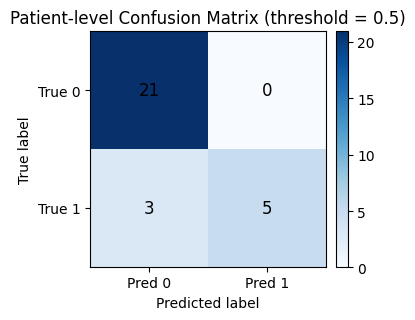

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

TP = 5
FP = 0
TN = 21
FN = 3

cm = np.array([[TN, FP],
               [FN, TP]])

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")

# Tick labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred 0", "Pred 1"])
ax.set_yticklabels(["True 0", "True 1"])

# Annotate cells
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j],
                ha="center", va="center", color="black", fontsize=12)

ax.set_title("Patient-level Confusion Matrix (threshold = 0.5)")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [ ]:
# Confusion matrix entries


# Metrics
accuracy    = (TP + TN) / (TP + TN + FP + FN)
specificity = TN / (TN + FP) if (TN + FP) > 0 else float('nan')
recall      = TP / (TP + FN) if (TP + FN) > 0 else float('nan')
precision   = TP / (TP + FP) if (TP + FP) > 0 else float('nan')
f1          = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else float('nan')

print("Accuracy   :", accuracy)
print("Specificity:", specificity)
print("Recall     :", recall)
print("F1 score   :", f1)


Accuracy   : 0.896551724137931
Specificity: 1.0
Recall     : 0.625
F1 score   : 0.7692307692307693


### Use Youden J

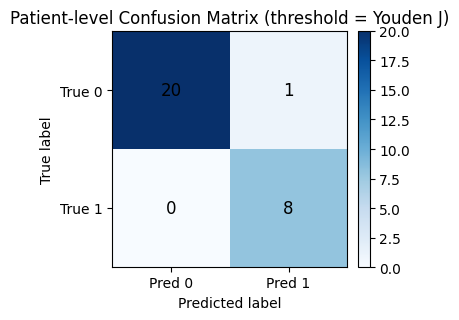

In [4]:
import numpy as np
import matplotlib.pyplot as plt

TP = 8
FP = 1
TN = 20
FN = 0

cm = np.array([[TN, FP],
               [FN, TP]])

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")

# Tick labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred 0", "Pred 1"])
ax.set_yticklabels(["True 0", "True 1"])

# Annotate cells
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j],
                ha="center", va="center", color="black", fontsize=12)

ax.set_title("Patient-level Confusion Matrix (threshold = Youden J)")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [5]:
# Metrics
accuracy    = (TP + TN) / (TP + TN + FP + FN)
specificity = TN / (TN + FP) if (TN + FP) > 0 else float('nan')
recall      = TP / (TP + FN) if (TP + FN) > 0 else float('nan')
precision   = TP / (TP + FP) if (TP + FP) > 0 else float('nan')
f1          = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else float('nan')

print("Accuracy   :", accuracy)
print("Specificity:", specificity)
print("Recall     :", recall)
print("F1 score   :", f1)


Accuracy   : 0.9655172413793104
Specificity: 0.9523809523809523
Recall     : 1.0
F1 score   : 0.9411764705882353
